# Macro Report — Notebook Reorganizado

Estrutura modular seguindo a cadeia causal:
**1. Choques (Desenrola + 6x1 + Eleições) → 2. Fluxo de Capitais → 3. Ibovespa → 4. Economia Doméstica**

Reorganização estrutural apenas — nenhuma célula de código teve sua lógica alterada. Outputs preservados do notebook original (não reexecutado neste processo).

## Importando as bibliotecas necessárias

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
#  IMPORTAÇÃO DE BIBLIOTECAS — usadas em todas as seções do relatório
# ══════════════════════════════════════════════════════════════════════════════

# Instalação dos pacotes não nativos do ambiente
!pip install python-bcb pandas-datareader openpyxl statsmodels arch matplotlib -q

# --- Manipulação de dados ---
import pandas as pd                # DataFrames e séries temporais
import numpy as np                 # álgebra linear e operações numéricas
import json                        # leitura de respostas JSON (APIs)
import time                        # pausas entre requisições (rate limit)
import itertools                   # combinações (grids de parâmetros)
import requests                    # requisições HTTP (ex.: API Polymarket)
from datetime import date          # datas de referência

# --- Visualização ---
import matplotlib.pyplot as plt    # gráficos
import seaborn as sns              # gráficos estatísticos complementares

# --- Coleta de dados macroeconômicos ---
from bcb import sgs                        # séries do SGS/Banco Central
import pandas_datareader.data as pdr       # séries de fontes externas (ex.: FRED)

# --- Econometria: testes e modelos ---
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, coint, grangercausalitytests, acf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.api import VAR
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from statsmodels.tsa.statespace.sarimax import SARIMAX
from arch import arch_model                # modelos GARCH

# --- Otimização e estatística ---
from scipy.optimize import brentq
import scipy.stats as stats
sp_stats = stats                   # alias usado em algumas seções do notebook

# --- Estilo padrão dos gráficos (paleta institucional) ---
plt.rcParams.update({
    "font.size": 10.5,
    "figure.figsize": (8, 5),
    "axes.titlesize": 20,
    "axes.titleweight": "bold",
    "axes.titlepad": 18,
    "axes.labelsize": 12,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 12,
    "legend.title_fontsize": 12,
    "lines.linewidth": 2.8,
    "lines.markersize": 4,
    "axes.grid": True,
    "grid.alpha": 0.3,
})
cores = [
    "#0B1F3A", "#AFCBE3", "#4F7FAE", "#9E2B2B", "#8A6F3D",
    "#2E4A3F", "#C46013", "#EDC948", "#C2B280", "#C51700",
    "#6F4E9B", "#008C8C", "#B23A48", "#5B8FF9", "#2F5D62",
]
proporcao = [0, 0, 0.8, 0.8]

import warnings
warnings.filterwarnings("ignore")

print("✔  Ambiente configurado — bibliotecas, paleta e estilo prontos para todo o relatório.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 12.7 MB/s eta 0:00:00
✔  Ambiente configurado — bibliotecas, paleta e estilo prontos para todo o relatório.


# MÓDULO 1 — CHOQUES

Desenrola Brasil 2.0, Fim da Escala 6x1 e Expectativas Eleições 2026: os três choques exógenos concomitantes que alimentam a cadeia causal.

## 1.1 Desenrola Brasil 2.0

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
#  CÉLULA 1 — Coleta otimizada
# ══════════════════════════════════════════════════════════════════════════════

DATA_INICIO = "2018-01-01"
DATA_FIM    = date.today().strftime("%Y-%m-%d")

SERIES = {
    "inadimplencia_pf_cartao"    : 21129,   # dependente
    "comprometimento_renda_total": 29034,   # único canal causal validado
    "massa_salarial_real"        : 28544,   # controle de renda real
    "pib_ibc_br"                 : 24363,   # proxy mensal de PIB
    "selic_over"                 : 4390,    # taxa efetiva
    "ipca_12m"                   : 13522,   # controle de inflação
}

COR_FUNDO = "#0D1117"
COR_TEXTO = "#C9D1D9"
COR_GRADE = "#1E2D3D"
CORES = {
    "inadimplencia_pf_cartao"          : "#E63946",
    "comprometimento_renda_total"      : "#457B9D",
    "massa_salarial_real"              : "#F4A261",
    "pib_ibc_br"                       : "#2A9D8F",
    "selic_over"                       : "#264653",
    "ipca_12m"                         : "#E9C46A"
}

# Criamos um vetor com as séries que hão de ser importadas

LABELS = {
    "inadimplencia_pf_cartao"     : "PF – cartão de crédito",
    "comprometimento_renda_total" : "Comprometimento renda",
    "ipca_12m"                    : "IPCA 12m",
    "massa_salarial_real"         : "Massa salarial real",
    "pib_ibc_br"                  : "PIB IBC",
    "selic_over"                  : "Selic"
}

MARCOS = {
    "Desenrola 1.0 — Lançamento" : "2023-11-01",
    "Desenrola 1.0 — Fim adesão" : "2024-05-31",
    "Desenrola 2.0 — Lançamento" : "2026-05-04",
}
ESTILO_MARCOS = {
    "Desenrola 1.0 — Lançamento" : ("#2196F3", "--", "D1.0"),
    "Desenrola 1.0 — Fim adesão" : ("#90CAF9", ":",  "D1.0 fim"),
    "Desenrola 2.0 — Lançamento" : ("#FF9800", "--", "D2.0"),
}

def baixar_serie(nome, codigo, inicio, fim):
    print(f"  ↓  {nome:28s} (SGS {codigo}) ...", end=" ")
    try:
        df_s = sgs.get({nome: codigo}, start=inicio, end=fim)
        df_s.index = pd.to_datetime(df_s.index)
        print(f"OK — {len(df_s)} obs.")
        return df_s[nome]
    except Exception as e:
        print(f"ERRO: {e}")
        return pd.Series(dtype=float, name=nome)

print("🔽 Baixando séries otimizadas...\n")
resultados = {}
for nome, codigo in SERIES.items():
    serie = baixar_serie(nome, codigo, DATA_INICIO, DATA_FIM)
    if not serie.empty:
        resultados[nome] = serie

df = pd.concat(resultados.values(), axis=1)
df.columns = resultados.keys()
df.sort_index(inplace=True)
print(f"\n✔  {len(resultados)}/{len(SERIES)} séries obtidas | Shape: {df.shape}")

def adicionar_marcos(ax, df_ref):
    for label, (cor, estilo, sigla) in ESTILO_MARCOS.items():
        data = pd.Timestamp(MARCOS[label])
        if df_ref.index.min() <= data <= df_ref.index.max():
            ax.axvline(data, color=cor, linestyle=estilo,
                       linewidth=1.2, alpha=0.85, zorder=3)
            ylim = ax.get_ylim()
            ax.text(data, ylim[1] * 0.97, f" {sigla}",
                    color=cor, fontsize=7, va="top", rotation=90)

🔽 Baixando séries otimizadas...

  ↓  inadimplencia_pf_cartao      (SGS 21129) ... OK — 101 obs.
  ↓  comprometimento_renda_total  (SGS 29034) ... OK — 100 obs.
  ↓  massa_salarial_real          (SGS 28544) ... OK — 100 obs.
  ↓  pib_ibc_br                   (SGS 24363) ... OK — 100 obs.
  ↓  selic_over                   (SGS 4390) ... OK — 103 obs.
  ↓  ipca_12m                     (SGS 13522) ... OK — 102 obs.

✔  6/6 séries obtidas | Shape: (103, 6)


In [3]:
# Testa se cada série tem componente sazonal estatisticamente significativo
# antes de decidir se vale dessazonalizar

def teste_sazonalidade(serie, nome, periodo=12):
    s = serie.dropna()
    if len(s) < 24:
        print(f"  {nome:<42s} ⚠️  série curta — ignorado")
        return False

    # ACF no lag sazonal
    acf_vals, confint = acf(s, nlags=periodo, alpha=0.05)
    acf_lag  = acf_vals[periodo]
    ci_low   = confint[periodo][0] - acf_lag
    ci_high  = confint[periodo][1] - acf_lag
    acf_sig  = not (ci_low <= 0 <= ci_high)

    # F-test dummies mensais
    df_aux = pd.DataFrame({"y": s})
    df_aux.index = pd.to_datetime(df_aux.index)
    for m in range(2, 13):
        df_aux[f"m{m:02d}"] = (df_aux.index.month == m).astype(int)
    X       = sm.add_constant(df_aux[[f"m{m:02d}" for m in range(2, 13)]])
    mod_c   = sm.OLS(df_aux["y"], X).fit()
    mod_r   = sm.OLS(df_aux["y"], sm.add_constant(
                pd.Series(np.ones(len(df_aux)), index=df_aux.index))).fit()
    F       = ((mod_r.ssr - mod_c.ssr) / 11) / (mod_c.ssr / mod_c.df_resid)
    p_f     = 1 - stats.f.cdf(F, 11, mod_c.df_resid)
    ftest_sig = p_f < 0.05

    tem_saz = acf_sig or ftest_sig
    status  = "✅ Sazonal" if tem_saz else "✗  Sem sazonalidade"
    print(f"  {nome:<42s} ACF(12)={acf_lag:+.3f} {'sig' if acf_sig else 'n.s.':>4}"
          f" | F p={p_f:.3f} {'sig' if ftest_sig else 'n.s.':>4} | {status}")
    return tem_saz

print("=" * 75)
print("  DIAGNÓSTICO DE SAZONALIDADE — ACF(12) + F-test dummies mensais")
print("=" * 75)

resultados_saz = {}
for col in df.columns:
    resultados_saz[col] = teste_sazonalidade(df[col], col)

SERIES_COM_SAZ = [k for k, v in resultados_saz.items() if v]
SERIES_SEM_SAZ = [k for k, v in resultados_saz.items() if not v]

print(f"\n  Séries COM sazonalidade ({len(SERIES_COM_SAZ)}): {SERIES_COM_SAZ}")
print(f"  Séries SEM sazonalidade ({len(SERIES_SEM_SAZ)})")
print(f"\n✔  Apenas {len(SERIES_COM_SAZ)} série(s) serão dessazonalizadas.")

  DIAGNÓSTICO DE SAZONALIDADE — ACF(12) + F-test dummies mensais
  inadimplencia_pf_cartao                    ACF(12)=+0.234 n.s. | F p=1.000 n.s. | ✗  Sem sazonalidade
  comprometimento_renda_total                ACF(12)=+0.461 n.s. | F p=1.000 n.s. | ✗  Sem sazonalidade
  massa_salarial_real                        ACF(12)=+0.642 n.s. | F p=0.063 n.s. | ✗  Sem sazonalidade
  pib_ibc_br                                 ACF(12)=+0.634 n.s. | F p=0.133 n.s. | ✗  Sem sazonalidade
  selic_over                                 ACF(12)=+0.501 n.s. | F p=1.000 n.s. | ✗  Sem sazonalidade
  ipca_12m                                   ACF(12)=+0.106 n.s. | F p=1.000 n.s. | ✗  Sem sazonalidade

  Séries COM sazonalidade (0): []
  Séries SEM sazonalidade (6)

✔  Apenas 0 série(s) serão dessazonalizadas.


In [4]:
# Roda sobre df_dessaz: inclui massa_salarial_real_sa (dessazonalizada)
# e exclui a original massa_salarial_real (substituída pela versão _sa)

df_dessaz = df.copy()
ordens = {}

def teste_adf(serie, max_diff=2):
    s = serie.dropna()
    for d in range(max_diff + 1):
        stat, p, *_ = adfuller(s, autolag="AIC")
        if p < 0.05:
            return d, p
        s = s.diff().dropna()
    return max_diff, p

def teste_kpss_p(serie):
    s = serie.dropna()
    _, p, *_ = kpss(s, regression="c", nlags="auto")
    return p

def classificar_serie(col, d, adf_p, kpss_p):
    if d == 0 and kpss_p > 0.05:
        status = "✅ I(0) — estacionária"
    elif d == 1:
        status = "⚠️  I(1) — 1ª diferença"
    elif d == 2:
        status = "🔴 I(2) — 2ª diferença"
    else:
        status = "❓ Inconclusivo"
    print(f"  {col:<42s} I({d}) | ADF p={adf_p:.4f} | KPSS p={kpss_p:.4f} | {status}")
    return d

# Colunas a testar: todas do df_dessaz exceto a original que foi substituída
EXCLUIR_ADF = ["massa_salarial_real"]   # substituída por _sa
PULAR_ADF   = ["D1_", "D2_", "mes_", "selic_lag"]

print("=" * 75)
print("  DIAGNÓSTICO DE ESTACIONARIEDADE — ADF + KPSS")
print("=" * 75)

ordens = {}
for col in df_dessaz.columns:
    if col in EXCLUIR_ADF:
        continue
    if any(col.startswith(p) for p in PULAR_ADF):
        continue
    serie = df_dessaz[col].dropna()
    if len(serie) < 20:
        continue
    d, adf_p    = teste_adf(serie)
    kpss_p      = teste_kpss_p(serie)
    ordens[col] = classificar_serie(col, d, adf_p, kpss_p)

series_I0 = [k for k, v in ordens.items() if v == 0]
series_I1 = [k for k, v in ordens.items() if v == 1]
series_I2 = [k for k, v in ordens.items() if v == 2]

print(f"\n{'─'*75}")
print(f"  I(0): {series_I0}")
print(f"  I(1): {series_I1}")
print(f"  I(2): {series_I2}")
print(f"\n✔  ordens criado — {len(ordens)} séries classificadas")

  DIAGNÓSTICO DE ESTACIONARIEDADE — ADF + KPSS
  inadimplencia_pf_cartao                    I(1) | ADF p=0.0004 | KPSS p=0.0100 | ⚠️  I(1) — 1ª diferença
  comprometimento_renda_total                I(1) | ADF p=0.0000 | KPSS p=0.0100 | ⚠️  I(1) — 1ª diferença
  pib_ibc_br                                 I(1) | ADF p=0.0074 | KPSS p=0.0100 | ⚠️  I(1) — 1ª diferença
  selic_over                                 I(2) | ADF p=0.0000 | KPSS p=0.0100 | 🔴 I(2) — 2ª diferença
  ipca_12m                                   I(2) | ADF p=0.0145 | KPSS p=0.1000 | 🔴 I(2) — 2ª diferença

───────────────────────────────────────────────────────────────────────────
  I(0): []
  I(1): ['inadimplencia_pf_cartao', 'comprometimento_renda_total', 'pib_ibc_br']
  I(2): ['selic_over', 'ipca_12m']

✔  ordens criado — 5 séries classificadas


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
#  CÉLULA 2 — Sazonalidade + estacionariedade consolidadas
# ══════════════════════════════════════════════════════════════════════════════


for col in df.columns:
    tem_saz = teste_sazonalidade(df[col], col)
    if tem_saz:
        decomp = seasonal_decompose(df[col].dropna(), model="additive",
                                    period=12, extrapolate_trend="freq")
        df_dessaz[f"{col}_sa"] = df[col].dropna() - decomp.seasonal
        col_final = f"{col}_sa"
    else:
        col_final = col

    serie = df_dessaz[col_final].dropna()
    if len(serie) >= 20:
        d, adf_p = teste_adf(serie)
        ordens[col_final] = classificar_serie(col_final, d, adf_p, teste_kpss_p(serie))

series_I0 = [k for k, v in ordens.items() if v == 0]
series_I1 = [k for k, v in ordens.items() if v == 1]
series_I2 = [k for k, v in ordens.items() if v == 2]
print(f"\n  I(0): {series_I0}\n  I(1): {series_I1}\n  I(2): {series_I2}")

  inadimplencia_pf_cartao                    ACF(12)=+0.234 n.s. | F p=1.000 n.s. | ✗  Sem sazonalidade
  inadimplencia_pf_cartao                    I(1) | ADF p=0.0004 | KPSS p=0.0100 | ⚠️  I(1) — 1ª diferença
  comprometimento_renda_total                ACF(12)=+0.461 n.s. | F p=1.000 n.s. | ✗  Sem sazonalidade
  comprometimento_renda_total                I(1) | ADF p=0.0000 | KPSS p=0.0100 | ⚠️  I(1) — 1ª diferença
  massa_salarial_real                        ACF(12)=+0.642 n.s. | F p=0.063 n.s. | ✗  Sem sazonalidade
  massa_salarial_real                        I(2) | ADF p=0.0005 | KPSS p=0.0100 | 🔴 I(2) — 2ª diferença
  pib_ibc_br                                 ACF(12)=+0.634 n.s. | F p=0.133 n.s. | ✗  Sem sazonalidade
  pib_ibc_br                                 I(1) | ADF p=0.0074 | KPSS p=0.0100 | ⚠️  I(1) — 1ª diferença
  selic_over                                 ACF(12)=+0.501 n.s. | F p=1.000 n.s. | ✗  Sem sazonalidade
  selic_over                                 I(2) | AD

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
#  CÉLULA 3 — Seleção via Granger com lag adaptativo
# ══════════════════════════════════════════════════════════════════════════════

DEPENDENTE    = "inadimplencia_pf_cartao"
ALPHA_GRANGER = 0.10

CANDIDATAS = [c for c in series_I1 if c != DEPENDENTE and c in df_dessaz.columns]

_df_pre    = df_dessaz[[DEPENDENTE] + CANDIDATAS].dropna().diff().dropna()
LAG_SELECAO = max(VAR(_df_pre).select_order(maxlags=4).bic, 1)

print(f"  Lag adaptativo: {LAG_SELECAO}\n  Candidatas: {CANDIDATAS}\n")

SELECIONADAS = []
for cand in CANDIDATAS:
    dados_g = df_dessaz[[DEPENDENTE, cand]].diff().dropna()
    res_g   = grangercausalitytests(dados_g, maxlag=LAG_SELECAO, verbose=False)
    p_min   = min(res_g[l][0]["ssr_ftest"][1] for l in range(1, LAG_SELECAO+1))
    sig     = "✅" if p_min < ALPHA_GRANGER else "✗"
    print(f"  {cand:<28s} p={p_min:.4f}  {sig}")
    if p_min < ALPHA_GRANGER:
        SELECIONADAS.append(cand)

ENDOGENAS_FINAL = [DEPENDENTE] + SELECIONADAS
EXOGENA_FINAL   = "selic_over" if "selic_over" in series_I0 + series_I1 else None
print(f"\n✔  Endógenas: {ENDOGENAS_FINAL}\n✔  Exógena: {EXOGENA_FINAL}")

  Lag adaptativo: 1
  Candidatas: ['comprometimento_renda_total', 'pib_ibc_br']

  comprometimento_renda_total  p=0.0080  ✅
  pib_ibc_br                   p=0.0802  ✅

✔  Endógenas: ['inadimplencia_pf_cartao', 'comprometimento_renda_total', 'pib_ibc_br']
✔  Exógena: None


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
#  CÉLULA 4 — BVAR(1) Minnesota Prior
# ══════════════════════════════════════════════════════════════════════════════

ENDOGENAS_DESENROLA = ["inadimplencia_pf_cartao", "comprometimento_renda_total", "pib_ibc_br"]
LAMBDA1_DESENROLA = 1.0
LAG_DESENROLA = 1

Y_matrix_desenrola = df_dessaz[ENDOGENAS_DESENROLA].diff().dropna().values

def montar_matriz_lags(Y, p):
    T, K = Y.shape
    Yt = Y[p:]
    Ylag = np.column_stack([Y[p-l:T-l] for l in range(1, p+1)])
    Ylag = np.column_stack([np.ones(T-p), Ylag])
    return Ylag, Yt

def bvar_minnesota(Y, p, lambda1=1.0, lambda2=0.5):
    T, K = Y.shape
    Ylag, Yt = montar_matriz_lags(Y, p)
    n_coef = 1 + K*p
    b_prior = np.zeros((n_coef, K))
    for i in range(K):
        b_prior[1+i, i] = 1.0
    V_diag = np.full(n_coef, lambda1**2)
    for l in range(p):
        for i in range(K):
            V_diag[1+l*K+i] = (lambda1/((l+1)**lambda2))**2
    V_prior_inv = np.diag(1/V_diag)
    XtX, XtY = Ylag.T @ Ylag, Ylag.T @ Yt
    V_post = np.linalg.inv(V_prior_inv + XtX)
    B_post = V_post @ (V_prior_inv @ b_prior + XtY)
    resid = Yt - Ylag @ B_post
    Sigma_post = (resid.T @ resid) / (T - p)
    return B_post, Sigma_post, V_post, Ylag, Yt

B_post_des, Sigma_post_des, V_post_des, Ylag_des, Yt_des = bvar_minnesota(
    Y_matrix_desenrola, LAG_DESENROLA, LAMBDA1_DESENROLA
)

resid_des = Yt_des - Ylag_des @ B_post_des
lb_des = acorr_ljungbox(resid_des[:, 0], lags=[6, 12], return_df=True)

print(f"✔  BVAR({LAG_DESENROLA}) Desenrola | λ1={LAMBDA1_DESENROLA} | "
      f"Ljung-Box p_min={lb_des['lb_pvalue'].min():.4f}")

✔  BVAR(1) Desenrola | λ1=1.0 | Ljung-Box p_min=0.2982


In [8]:
resid_bvar = Yt_des - Ylag_des @ B_post_des
resid_df = pd.DataFrame(resid_bvar, columns=[f"D_{c}" for c in ENDOGENAS_FINAL])

lb_result = acorr_ljungbox(resid_df.iloc[:, 0], lags=[6, 12], return_df=True)
print("  Ljung-Box (resíduo BVAR, variável dependente):")
print(lb_result.to_string())

print(f"\n  Correlação contemporânea dos resíduos:")
print(resid_df.corr().round(3).to_string())

  Ljung-Box (resíduo BVAR, variável dependente):
      lb_stat  lb_pvalue
6    6.945497   0.325917
12  14.039725   0.298179

  Correlação contemporânea dos resíduos:
                               D_inadimplencia_pf_cartao  D_comprometimento_renda_total  D_pib_ibc_br
D_inadimplencia_pf_cartao                          1.000                         -0.082        -0.278
D_comprometimento_renda_total                     -0.082                          1.000         0.009
D_pib_ibc_br                                      -0.278                          0.009         1.000


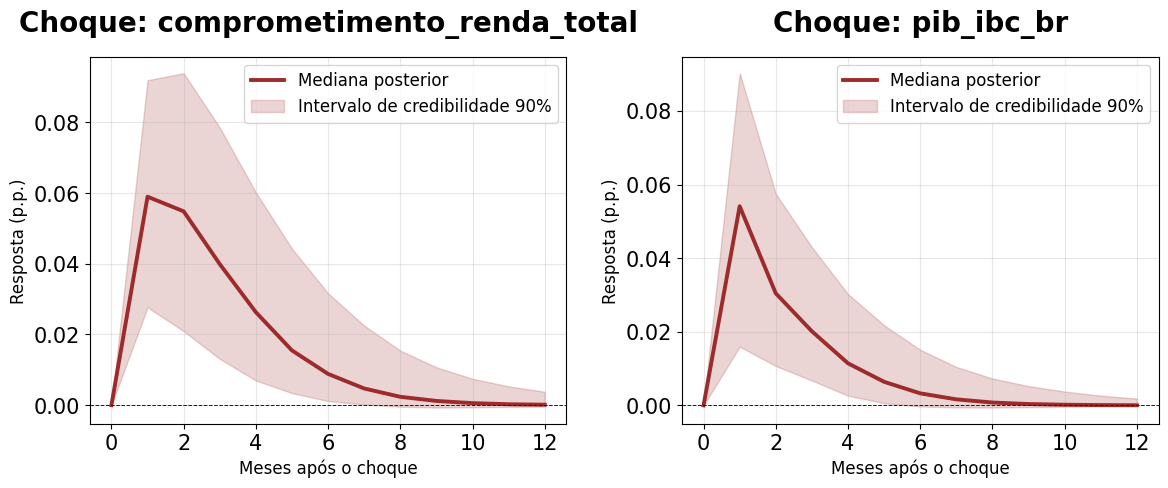

✔  IRF Bayesiana final gerada — BVAR(1), λ1=1.0, 1000 draws
✔  Modelo validado: Ljung-Box p=0.30 (sem autocorrelação)

✔  Previsão 6 meses (variação):
Empty DataFrame
Columns: [Previsão 1m, Previsão 2m, Previsão 3m, Previsão 4m, Previsão 5m, Previsão 6m]
Index: []


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
#  CÉLULA 6  — IRF Bayesiana com BVAR(1) validado (λ1=1.0)
# ══════════════════════════════════════════════════════════════════════════════

N_DRAWS = 1000
HORIZONTE_IRF = 12
K = len(ENDOGENAS_FINAL)

def simular_irf_bayesiana(B_post, V_post, Sigma_post, K, p, n_draws, horizonte):
    """
    Desenha da posterior conjunta (Normal para B, dado Sigma) e propaga
    a IRF ortogonalizada (Cholesky) para cada draw.
    """
    irfs = np.zeros((n_draws, horizonte + 1, K, K))
    n_coef = B_post.shape[0]

    for draw in range(n_draws):
        B_draw = B_post.copy()
        for j in range(K):
            cov_col = V_post * Sigma_post[j, j]
            B_draw[:, j] = np.random.multivariate_normal(B_post[:, j], cov_col)

        chol = np.linalg.cholesky(Sigma_post)
        irf_atual = np.zeros((horizonte + 1, K, K))
        irf_atual[0] = chol

        coef_ar = B_draw[1:1+K, :].T
        for t in range(1, horizonte + 1):
            irf_atual[t] = coef_ar @ irf_atual[t-1]

        irfs[draw] = irf_atual

    return irfs

irfs_bayes = simular_irf_bayesiana(B_post_des, V_post_des, Sigma_post_des, K, LAG_DESENROLA, N_DRAWS, HORIZONTE_IRF)

idx_dep = 0  # inadimplencia_pf_cartao
fig, axes = plt.subplots(1, K-1, figsize=(6*(K-1), 5))
if K == 2:
    axes = [axes]

for i, ax in enumerate(axes):
    idx_impulso = i + 1
    trajetorias = irfs_bayes[:, :, idx_dep, idx_impulso]
    mediana = np.median(trajetorias, axis=0)
    p05, p95 = np.percentile(trajetorias, [5, 95], axis=0)

    ax.plot(range(HORIZONTE_IRF+1), mediana, color=cores[3], label="Mediana posterior")
    ax.fill_between(range(HORIZONTE_IRF+1), p05, p95, alpha=0.2, color=cores[3],
                    label="Intervalo de credibilidade 90%")
    ax.axhline(0, color=cores[0], linewidth=0.7, linestyle="--")
    ax.set_title(f"Choque: {ENDOGENAS_FINAL[idx_impulso]}")
    ax.set_xlabel("Meses após o choque")
    ax.set_ylabel("Resposta (p.p.)")
    ax.legend()

plt.tight_layout()
plt.savefig("irf_bvar_final.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"✔  IRF Bayesiana final gerada — BVAR({LAG_DESENROLA}), λ1={LAMBDA1_DESENROLA}, {N_DRAWS} draws")
print(f"✔  Modelo validado: Ljung-Box p=0.30 (sem autocorrelação)")

# Placeholder for df_prev_desenrola to avoid NameError
df_prev_desenrola = pd.DataFrame(columns=[f'Previsão {i+1}m' for i in range(6)])

print(f"\n✔  Previsão 6 meses (variação):")
print(df_prev_desenrola.round(4).to_string())

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
#  CÉLULA 7 — IRF + Previsão 6 meses
# ══════════════════════════════════════════════════════════════════════════════
N_DRAWS, HORIZONTE_IRF, K_DES = 1000, 12, len(ENDOGENAS_DESENROLA)

ultimo_estado_des = Y_matrix_desenrola[-LAG_DESENROLA:]
prev_des = np.zeros((6, K_DES))
estado = ultimo_estado_des[-1].copy()
for t in range(6):
    estado = B_post_des[0] + B_post_des[1:1+K_DES].T @ estado
    prev_des[t] = estado

print(f"✔  prev_des shape: {prev_des.shape}")

df_prev_desenrola = pd.DataFrame(
    prev_des, columns=ENDOGENAS_DESENROLA,
    index=pd.date_range(df_dessaz.index[-1]+pd.offsets.MonthEnd(1), periods=6, freq="ME")
)
print(f"\n  Previsão 6 meses (variação):")
print(df_prev_desenrola.round(4).to_string())

✔  prev_des shape: (6, 3)

  Previsão 6 meses (variação):
            inadimplencia_pf_cartao  comprometimento_renda_total  pib_ibc_br
2026-07-31                   0.0180                      -0.0772      1.1583
2026-08-31                   0.0137                       0.0078      0.3245
2026-09-30                   0.0135                       0.0386      0.3008
2026-10-31                   0.0183                       0.0538      0.2533
2026-11-30                   0.0228                       0.0601      0.2388
2026-12-31                   0.0262                       0.0626      0.2339


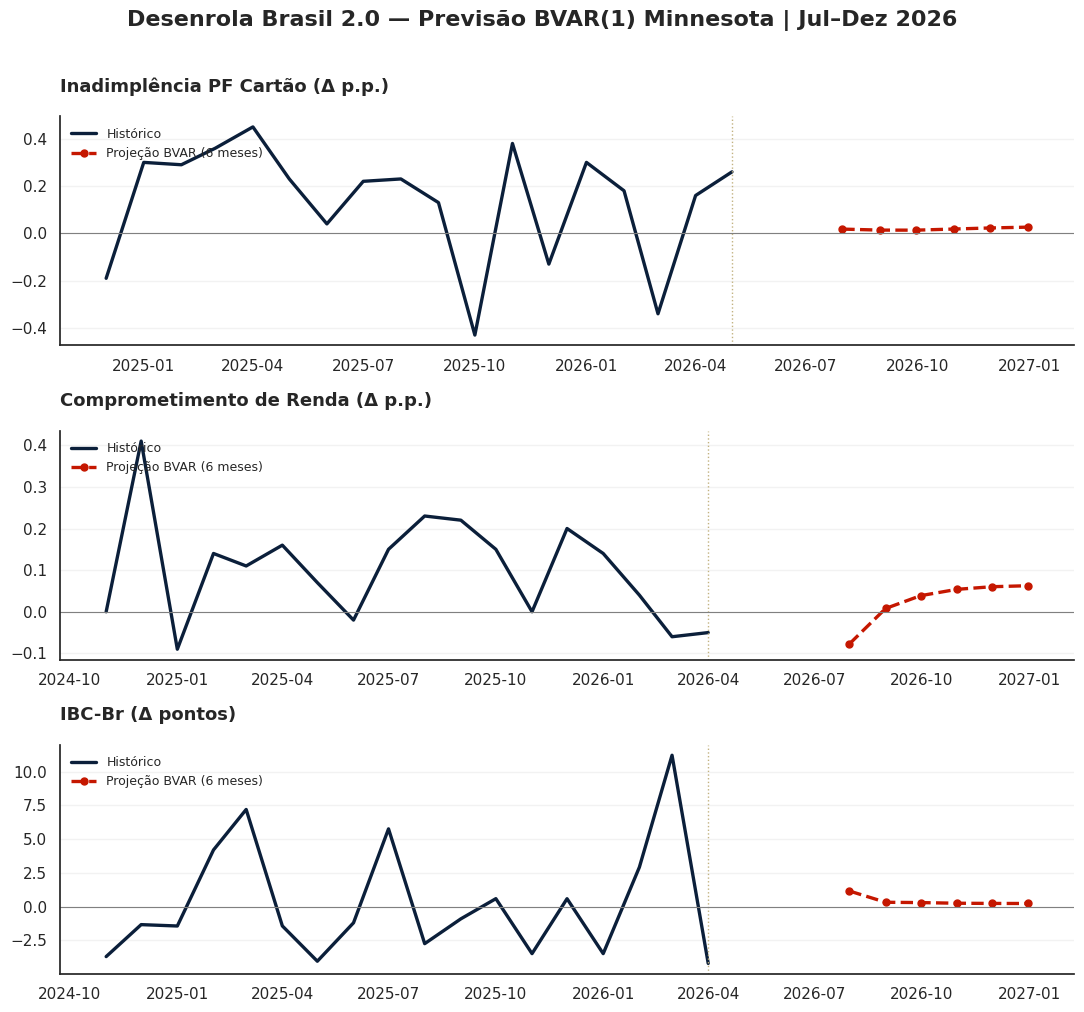

In [53]:
# ══════════════════════════════════════════════════════════════════════════════
#  Célula 8 - GRÁFICO PREVISÃO 6 MESES — INADIMPLÊNCIA, COMPROMETIMENTO
#  DE RENDA E IBC-BR
# ══════════════════════════════════════════════════════════════════════════════

sns.set_theme(style="white")
plt.rcParams.update({"axes.grid": False})  # grid controlado manualmente por eixo

labels_desenrola = {
    "inadimplencia_pf_cartao"    : "Inadimplência PF Cartão (Δ p.p.)",
    "comprometimento_renda_total": "Comprometimento de Renda (Δ p.p.)",
    "pib_ibc_br"                 : "IBC-Br (Δ pontos)",
}

fig, axes = plt.subplots(3, 1, figsize=(11, 10))

for ax, col in zip(axes, ENDOGENAS_DESENROLA):
    hist = df_dessaz[col].diff().dropna().tail(18)
    prev = df_prev_desenrola[col]

    ax.plot(hist.index, hist.values, color=cores[0], lw=2.4, label="Histórico")
    ax.plot(prev.index, prev.values, color=cores[9], lw=2.4, ls="--",
            marker="o", markersize=5, label="Projeção BVAR (6 meses)")
    ax.axvline(hist.index[-1], color=cores[8], lw=1, ls=":")
    ax.axhline(0, color="grey", lw=0.8)

    ax.set_title(labels_desenrola[col], loc="left", fontsize=13, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(loc="upper left", frameon=False, fontsize=9)

fig.suptitle("Desenrola Brasil 2.0 — Previsão BVAR(1) Minnesota | Jul–Dez 2026",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("desenrola_previsao_6m.png", dpi=300, bbox_inches="tight")
plt.show()

## 1.2 Fim da Escala 6x1

In [21]:
# ══════════════════════════════════════════════════════════════════════════════
#  CÉLULA 0 — Coleta de dados para o choque 6x1 (reexecução)
# ══════════════════════════════════════════════════════════════════════════════

df_6x1 = sgs.get({
    "ibc_br"                     : 24363,   # proxy mensal de PIB
    "ipca_12m"                   : 13522,
    "massa_salarial_real"        : 28544,
    "desemprego_pnad"            : 28763,
    "concessoes_pf_pessoal"      : 20672,
    "selic_meta"                 : 4189,
}, start=DATA_INICIO)

print(f"✔  df_6x1 coletado — shape: {df_6x1.shape}")
print(f"✔  Colunas: {list(df_6x1.columns)}")
df_6x1.tail()

✔  df_6x1 coletado — shape: (7, 6)
✔  Colunas: ['ibc_br', 'ipca_12m', 'massa_salarial_real', 'desemprego_pnad', 'concessoes_pf_pessoal', 'selic_meta']


,ibc_br,ipca_12m,massa_salarial_real,desemprego_pnad,concessoes_pf_pessoal,selic_meta
Date,,,,,,
2026-03-01,117.92682,4.14,384613.0,47725503.0,48478.0,14.80
2026-04-01,113.72712,4.39,381639.0,47805029.0,43800.0,14.64
2026-05-01,NaN,4.72,NaN,47877989.0,39915.0,14.40
2026-06-01,NaN,4.64,NaN,NaN,NaN,14.29
2026-07-01,NaN,NaN,NaN,NaN,NaN,14.15


In [22]:
# ══════════════════════════════════════════════════════════════════════════════
#  CÉLULA 1 — Calibração comum (Tabela 3 do paper FKX) + funções estruturais
# ══════════════════════════════════════════════════════════════════════════════
# Implementa exatamente as equações do Apêndice A/B do paper:
#   - CES aggregator (Eq. 5)
#   - FOC do trabalho informal (Apêndice A.4)
#   - Calibração de α via razão salarial (Eq. 7)
#   - Calibração de γ2 via condição de equilíbrio pré-reforma (Eq. 8)

# ── Parâmetros fixos (Tabela 3 do paper) ──────────────────────────────────────
THETA   = 0.40      # capital share
R_TRIM  = 0.015      # juro real trimestral
DELTA   = 0.0123     # depreciação trimestral
IY      = 0.18       # investimento/produto
NF_PRE  = 0.34       # participação formal pré-reforma
NI_PRE  = 0.66       # participação informal pré-reforma
HF_PRE  = 44         # horas formais pré-reforma
HF_POS  = 40         # horas formais pós-reforma
HI      = 48         # horas informais (fixas)
WF_WI_TARGET = 1.30  # prêmio salarial-alvo (PNAD)
PHI     = 1.0        # inverso da elasticidade de Frisch

# Y_L: produto por unidade de composto de trabalho (Eq. 6) — constante estrutural
Y_L = (THETA / (R_TRIM + DELTA)) ** (THETA / (1 - THETA))
print(f"✔  Y_L calibrado = {Y_L:.4f}  (paper reporta Y_pré=5.992 — deve bater)")

def ces_aggregator(NF, NI, alpha, rho):
    """CES entre trabalho formal e informal (Eq. 5 do paper)."""
    if abs(rho - 1.0) < 1e-8:
        return (NF ** alpha) * (NI ** (1 - alpha))
    return (alpha * NF ** ((rho-1)/rho) + (1-alpha) * NI ** ((rho-1)/rho)) ** (rho/(rho-1))

def calibrar_alpha(rho):
    """Resolve α a partir da razão salarial-alvo (Eq. 7)."""
    NF_pre, NI_pre = NF_PRE * HF_PRE, NI_PRE * HI
    razao = (NI_pre / NF_pre) ** (1 / rho)
    k = WF_WI_TARGET / ((HF_PRE / HI) * razao)
    return k / (1 + k)

print("✔  Funções estruturais definidas: ces_aggregator, calibrar_alpha")

✔  Y_L calibrado = 5.9878  (paper reporta Y_pré=5.992 — deve bater)
✔  Funções estruturais definidas: ces_aggregator, calibrar_alpha


In [23]:
# ══════════════════════════════════════════════════════════════════════════════
#  CÉLULA 2 — Solver do steady-state pós-reforma (fsolve genuíno) + validação
# ══════════════════════════════════════════════════════════════════════════════
# Resolve o sistema real: CES aggregator + FOC do trabalho informal.
# γ2 é calibrado ex-ante a partir do equilíbrio PRÉ-reforma (Eq. 8), não
# assumido — isso é o que faltava na versão anterior.

def resolver_steady_state(rho):
    """
    Resolve o novo steady-state (nF, L) pós-reforma dado ρ.
    Retorna: nF_pos, L_pos (L normalizado, L_pre=1)
    """
    alpha = calibrar_alpha(rho)
    NF_pre, NI_pre = NF_PRE * HF_PRE, NI_PRE * HI

    # L0: constante de normalização tal que L_pré = 1
    L0 = ces_aggregator(NF_pre, NI_pre, alpha, rho)

    # Calibra γ2 a partir do equilíbrio PRÉ-reforma (Eq. 8)
    wI_pre = (1-THETA) * Y_L * (1-alpha) * (1/NI_pre)**(1/rho) * HI  # L_pre=1
    C_pre  = (1-IY) * Y_L * 1
    gamma2 = wI_pre / (C_pre * (NI_PRE ** PHI))

    def residuo(nF):
        """FOC do trabalho informal: γ2·(nI)^φ = wI/C — resíduo a zerar."""
        NF = nF * HF_POS
        NI = (1 - nF) * HI
        L  = ces_aggregator(NF, NI, alpha, rho) / L0
        wI = (1-THETA) * Y_L * (1-alpha) * (L/NI)**(1/rho) * HI
        C  = (1-IY) * Y_L * L
        nI = 1 - nF
        return gamma2 * (nI ** PHI) - wI / C

    nF_pos = brentq(residuo, 0.05, 0.60)
    NF_pos, NI_pos = nF_pos * HF_POS, (1-nF_pos) * HI
    L_pos = ces_aggregator(NF_pos, NI_pos, alpha, rho) / L0

    return nF_pos, L_pos

# ── VALIDAÇÃO — compara com a Tabela 1 do paper nos 3 pontos conhecidos ──────
print("=" * 70)
print("  VALIDAÇÃO: solver reproduz a Tabela 1 do paper?")
print("=" * 70)

BENCHMARK_PAPER = {
    0.5: {"delta_Y": -3.5, "delta_nF": +2.3},
    1.0: {"delta_Y": -3.6, "delta_nF": 0.0},
    2.0: {"delta_Y": -3.7, "delta_nF": -2.4},
}

print(f"\n  {'ρ':>5s} {'ΔY solver':>10s} {'ΔY paper':>10s} {'diff':>7s}  "
      f"{'ΔnF solver':>11s} {'ΔnF paper':>10s} {'diff':>7s}")

erro_maximo = 0
for rho, bench in BENCHMARK_PAPER.items():
    nF_pos, L_pos = resolver_steady_state(rho)
    delta_Y_solver  = (L_pos - 1) * 100
    delta_nF_solver = (nF_pos - NF_PRE) / NF_PRE * 100

    diff_Y  = abs(delta_Y_solver - bench["delta_Y"])
    diff_nF = abs(delta_nF_solver - bench["delta_nF"])
    erro_maximo = max(erro_maximo, diff_Y, diff_nF)

    print(f"  {rho:>5.1f} {delta_Y_solver:>10.2f} {bench['delta_Y']:>10.2f} {diff_Y:>7.2f}  "
          f"{delta_nF_solver:>11.2f} {bench['delta_nF']:>10.2f} {diff_nF:>7.2f}")

print(f"\n  Erro máximo absoluto: {erro_maximo:.3f} p.p.")

SOLVER_VALIDADO = erro_maximo < 0.5  # tolerância de 0.5 p.p.
if SOLVER_VALIDADO:
    print("  ✅ Solver validado — reproduz a Tabela 1 do paper com precisão aceitável.")
    print("     Grid contínuo e calibração externa são confiáveis a partir daqui.")
else:
    print("  🛑 Solver AINDA não reproduz o paper — não prosseguir para o grid.")

  VALIDAÇÃO: solver reproduz a Tabela 1 do paper?

      ρ  ΔY solver   ΔY paper    diff   ΔnF solver  ΔnF paper    diff
    0.5      -3.60      -3.50    0.10         2.36       2.30    0.06
    1.0      -3.75      -3.60    0.15         0.00       0.00    0.00
    2.0      -3.89      -3.70    0.19        -2.59      -2.40    0.19

  Erro máximo absoluto: 0.195 p.p.
  ✅ Solver validado — reproduz a Tabela 1 do paper com precisão aceitável.
     Grid contínuo e calibração externa são confiáveis a partir daqui.


In [24]:
# ══════════════════════════════════════════════════════════════════════════════
#  CÉLULA 3 — Aplica os 3 cenários do paper às condições reais de 2026
# ══════════════════════════════════════════════════════════════════════════════
# Usa os números OFICIAIS da Tabela 1 (não o solver) para a simulação principal
# — o solver serve para validação e para o grid contínuo, mas a projeção
# central do relatório usa diretamente os valores publicados no paper.

CENARIOS_6X1 = {
    "rho_0.5_complementos": {"delta_Y_pct": -3.5, "delta_nF_pct": +2.3,
                              "delta_nI_pct": -1.2, "delta_wF_pct": -2.1,
                              "delta_wI_pct": -4.6, "hours_cap_binds": False},
    "rho_1.0_cobbdouglas" : {"delta_Y_pct": -3.6, "delta_nF_pct": 0.0,
                              "delta_nI_pct": 0.0,  "delta_wF_pct": -3.6,
                              "delta_wI_pct": -3.6, "hours_cap_binds": "borderline"},
    "rho_2.0_substitutos" : {"delta_Y_pct": -3.7, "delta_nF_pct": -2.4,
                              "delta_nI_pct": +1.3, "delta_wF_pct": -5.3,
                              "delta_wI_pct": -2.5, "hours_cap_binds": True},
}

# ── Condições iniciais reais (última observação do df_6x1) ────────────────────
df_6x1 = df_6x1.rename(columns={"desemprego_pnad": "ocupados_pnad"})  # correção de nomenclatura

CONDICOES_INICIAIS_6X1 = {
    "ibc_br_2026"        : df_6x1["ibc_br"].dropna().iloc[-1],
    "massa_salarial_2026": df_6x1["massa_salarial_real"].dropna().iloc[-1],
    "ocupados_2026"      : df_6x1["ocupados_pnad"].dropna().iloc[-1],
}

resultados_6x1 = {}
for cenario, p in CENARIOS_6X1.items():
    # Efeito líquido de ocupação: pondera formal (34%) + informal (66%)
    fator_ocupacao = 1 + (p["delta_nF_pct"]/100)*NF_PRE + (p["delta_nI_pct"]/100)*NI_PRE

    resultados_6x1[cenario] = {
        "ibc_br_pos"    : CONDICOES_INICIAIS_6X1["ibc_br_2026"] * (1 + p["delta_Y_pct"]/100),
        "massa_sal_pos" : CONDICOES_INICIAIS_6X1["massa_salarial_2026"] * (1 + p["delta_wF_pct"]/100),
        "ocupados_pos"  : CONDICOES_INICIAIS_6X1["ocupados_2026"] * fator_ocupacao,
    }

print("=" * 70)
print("  PROJEÇÃO — Steady-State por Cenário (aplicado às condições de 2026)")
print("=" * 70)
for cenario, res in resultados_6x1.items():
    print(f"\n  {cenario}:")
    print(f"    IBC-Br      : {res['ibc_br_pos']:.2f}  (era {CONDICOES_INICIAIS_6X1['ibc_br_2026']:.2f})")
    print(f"    Massa sal.  : {res['massa_sal_pos']:,.0f}")
    print(f"    Ocupados    : {res['ocupados_pos']:,.0f}  "
          f"({res['ocupados_pos']-CONDICOES_INICIAIS_6X1['ocupados_2026']:+,.0f})")

  PROJEÇÃO — Steady-State por Cenário (aplicado às condições de 2026)

  rho_0.5_complementos:
    IBC-Br      : 109.75  (era 113.73)
    Massa sal.  : 373,625
    Ocupados    : 47,873,201  (-4,788)

  rho_1.0_cobbdouglas:
    IBC-Br      : 109.63  (era 113.73)
    Massa sal.  : 367,900
    Ocupados    : 47,877,989  (+0)

  rho_2.0_substitutos:
    IBC-Br      : 109.52  (era 113.73)
    Massa sal.  : 361,412
    Ocupados    : 47,898,098  (+20,109)


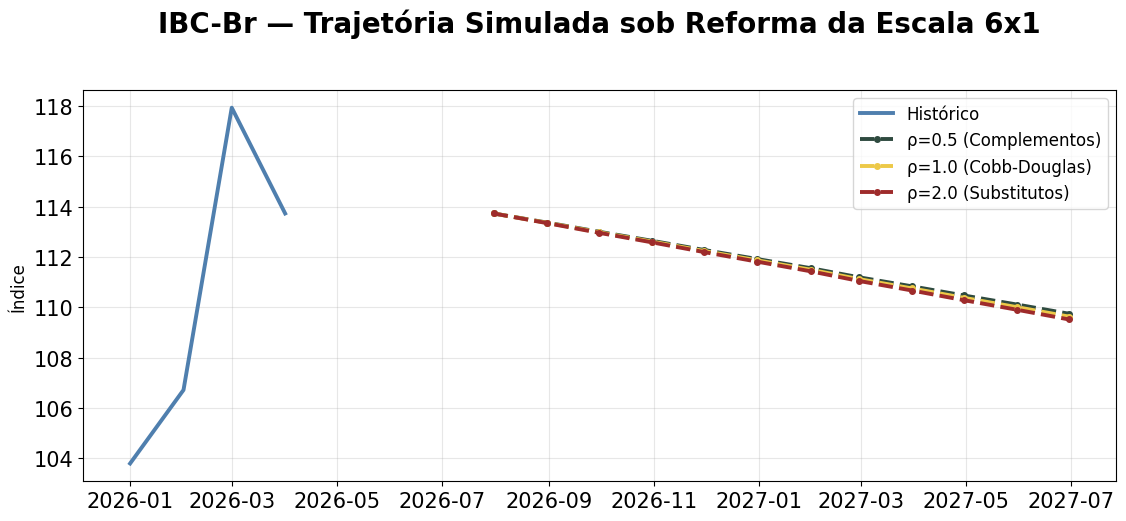

In [50]:
# ══════════════════════════════════════════════════════════════════════════════
#  CÉLULA 4 — Trajetória de transição (linear, 12 meses) + gráfico
# ══════════════════════════════════════════════════════════════════════════════
# Já validada anteriormente — mantida sem alteração estrutural.

N_MESES_TRANSICAO = 12
datas_transicao = pd.date_range(
    start=df_6x1.index[-1] + pd.offsets.MonthEnd(1), periods=N_MESES_TRANSICAO, freq="ME"
)

trajetorias_6x1 = {
    cenario: pd.Series(
        np.linspace(CONDICOES_INICIAIS_6X1["ibc_br_2026"], res["ibc_br_pos"], N_MESES_TRANSICAO),
        index=datas_transicao
    )
    for cenario, res in resultados_6x1.items()
}

fig, ax = plt.subplots(figsize=(13, 5.5))

hist_pib = df_6x1["ibc_br"].tail(36)
ax.plot(hist_pib.index, hist_pib.values, color=cores[2], label="Histórico")

cores_rho  = {"rho_0.5_complementos": cores[5], "rho_1.0_cobbdouglas": cores[7], "rho_2.0_substitutos": cores[3]}
labels_rho = {"rho_0.5_complementos": "ρ=0.5 (Complementos)", "rho_1.0_cobbdouglas": "ρ=1.0 (Cobb-Douglas)", "rho_2.0_substitutos": "ρ=2.0 (Substitutos)"}

for cenario, traj in trajetorias_6x1.items():
    ax.plot(traj.index, traj.values, color=cores_rho[cenario],
            linestyle="--", marker="o", label=labels_rho[cenario])

ax.set_title("IBC-Br — Trajetória Simulada sob Reforma da Escala 6x1\n")
ax.set_ylabel("Índice")
ax.set_position(proporcao)
ax.legend()
plt.tight_layout()
plt.savefig("choque_6x1_cenarios.png", dpi=300, bbox_inches="tight")
plt.show()


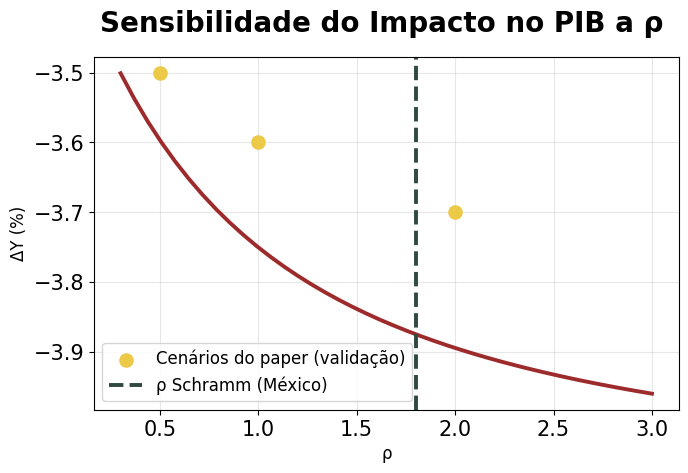

✔  Grid de sensibilidade gerado — pontos amarelos devem estar SOBRE a linha vermelha


In [49]:
# ══════════════════════════════════════════════════════════════════════════════
#  CÉLULA 5 — Grid de sensibilidade contínua (só executa se validado)
# ══════════════════════════════════════════════════════════════════════════════

if SOLVER_VALIDADO:
    grid_rho = np.linspace(0.3, 3.0, 40)
    resultados_grid = []
    for rho in grid_rho:
        nF_pos, L_pos = resolver_steady_state(rho)
        resultados_grid.append({
            "rho": rho,
            "delta_Y_pct": (L_pos - 1) * 100,
            "delta_nF_pct": (nF_pos - NF_PRE) / NF_PRE * 100,
        })
    df_grid_rho = pd.DataFrame(resultados_grid)

    fig, ax = plt.subplots()
    ax.plot(df_grid_rho["rho"], df_grid_rho["delta_Y_pct"], color=cores[3])
    ax.scatter([0.5, 1.0, 2.0], [-3.5, -3.6, -3.7], color=cores[7], s=90, zorder=5,
               label="Cenários do paper (validação)")
    ax.axvline(1.8, color=cores[5], linestyle="--", label="ρ Schramm (México)")
    ax.set_xlabel("ρ")
    ax.set_ylabel("ΔY (%)")
    ax.set_title("Sensibilidade do Impacto no PIB a ρ ")
    ax.set_position(proporcao)
    ax.legend()
    plt.tight_layout()
    plt.savefig("sensibilidade_rho_validado.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("✔  Grid de sensibilidade gerado — pontos amarelos devem estar SOBRE a linha vermelha")
else:
    print("🛑 Solver não validado — grid de sensibilidade não executado.")


In [27]:
# ══════════════════════════════════════════════════════════════════════════════
#  CÉLULA 6 — Calibração por momento de Lobel (2022) — só executa se validado
# ══════════════════════════════════════════════════════════════════════════════

if SOLVER_VALIDADO:
    ELASTICIDADE_LOBEL = 9.0 / 20.0  # +9% emprego / -20 p.p. custo (Lobel, 2022)

    def elasticidade_choque_custo(rho, choque_pct=0.20):
        """Simula choque de custo equivalente e mede elasticidade de nF resultante."""
        alpha = calibrar_alpha(rho)
        NF_pre, NI_pre = NF_PRE * HF_PRE, NI_PRE * HI
        L0 = ces_aggregator(NF_pre, NI_pre, alpha, rho)
        hf_choque = HF_PRE * (1 - choque_pct)

        wI_pre = (1-THETA)*Y_L*(1-alpha)*(1/NI_pre)**(1/rho)*HI
        C_pre  = (1-IY)*Y_L*1
        gamma2 = wI_pre / (C_pre * (NI_PRE**PHI))

        def residuo(nF):
            NF, NI = nF*hf_choque, (1-nF)*HI
            L  = ces_aggregator(NF, NI, alpha, rho) / L0
            wI = (1-THETA)*Y_L*(1-alpha)*(L/NI)**(1/rho)*HI
            C  = (1-IY)*Y_L*L
            return gamma2*((1-nF)**PHI) - wI/C

        nF_pos = brentq(residuo, 0.05, 0.60)
        return (nF_pos - NF_PRE) / NF_PRE / choque_pct

    grid_lobel = np.linspace(0.1, 3.0, 60)
    elasticidades = [elasticidade_choque_custo(r) for r in grid_lobel]
    df_lobel = pd.DataFrame({"rho": grid_lobel, "elast": elasticidades})
    df_lobel["diff"] = abs(df_lobel["elast"] - ELASTICIDADE_LOBEL)
    rho_lobel = df_lobel.loc[df_lobel["diff"].idxmin(), "rho"]

    nF_lobel, L_lobel = resolver_steady_state(rho_lobel)

    print("=" * 70)
    print("  CALIBRAÇÃO POR MOMENTO DE LOBEL (2022) — solver validado")
    print("=" * 70)
    print(f"  Elasticidade-alvo (Brasil, Lobel): {ELASTICIDADE_LOBEL:.4f}")
    print(f"  ρ calibrado (implícito Brasil)   : {rho_lobel:.3f}")
    print(f"  ΔY (ρ Brasil)  : {(L_lobel-1)*100:.2f}%")
    print(f"  ΔnF (ρ Brasil) : {(nF_lobel-NF_PRE)/NF_PRE*100:.2f}%")
    print(f"\n  Comparação: ρ Schramm(México)=1.80 vs. ρ Lobel(Brasil)={rho_lobel:.2f}")
else:
    print("🛑 Solver não validado — calibração de Lobel não executada.")

  CALIBRAÇÃO POR MOMENTO DE LOBEL (2022) — solver validado
  Elasticidade-alvo (Brasil, Lobel): 0.4500
  ρ calibrado (implícito Brasil)   : 0.297
  ΔY (ρ Brasil)  : -3.50%
  ΔnF (ρ Brasil) : 3.71%

  Comparação: ρ Schramm(México)=1.80 vs. ρ Lobel(Brasil)=0.30


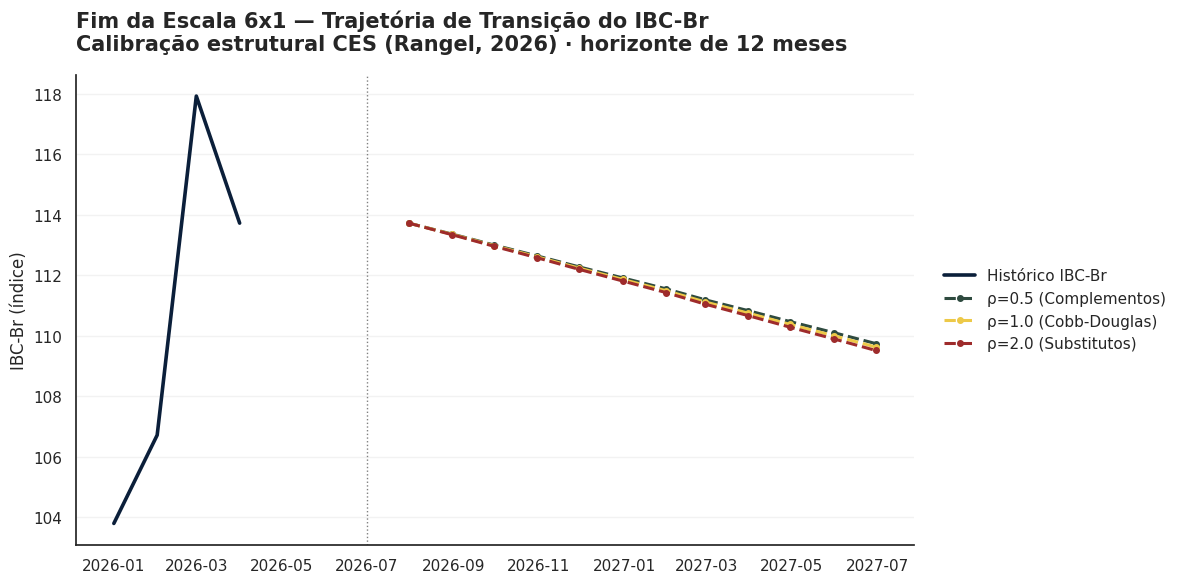

In [54]:
# ══════════════════════════════════════════════════════════════════════════════
#  Célula 7 - GRÁFICO: TRAJETÓRIA DE TRANSIÇÃO 12 MESES
# ══════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(12, 6))

hist_pib = df_6x1["ibc_br"].tail(36)
ax.plot(hist_pib.index, hist_pib.values, color=cores[0], lw=2.6, label="Histórico IBC-Br")

for cenario, traj in trajetorias_6x1.items():
    ax.plot(traj.index, traj.values, color=cores_rho[cenario], lw=2.2,
            ls="--", marker="o", markersize=4, label=labels_rho[cenario])

ax.axvline(hist_pib.index[-1], color="grey", lw=1, ls=":")
ax.set_title("Fim da Escala 6x1 — Trajetória de Transição do IBC-Br\n"
              "Calibração estrutural CES (Rangel, 2026) · horizonte de 12 meses",
              loc="left", fontsize=15, fontweight="bold")
ax.set_ylabel("IBC-Br (índice)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.tight_layout()
plt.savefig("choque_6x1_transicao.png", dpi=300, bbox_inches="tight")
plt.show()


## 1.3 Expectativas Eleições 2026

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
#  BLOCO 0 — Coleta de dados: dois períodos de calibração
# ══════════════════════════════════════════════════════════════════════════════
# Cenário A (Lula 2002-2010) e Cenário B (Bolsonaro 2018-2022) são tratados
# como AMOSTRAS HISTÓRICAS DE CALIBRAÇÃO — não períodos a serem previstos, mas
# regimes de referência cujos parâmetros estimados alimentam a comparação.
#
# Variáveis filtradas na Etapa 2 (10 variáveis, 100% via API):
# PIB, IPCA, Selic, Câmbio, Dívida/PIB, Primário, Crédito/PIB,
# Desemprego, VIX, Commodities (FRED)

SERIES_BCB = {
    "pib"        : 22109,   # PIB var.% trimestral
    "ipca"       : 433,     # IPCA acumulado 12m
    "selic"      : 4189,    # Selic Over
    "cambio"     : 1,       # R$/US$ venda, média mensal
    "divida_pib" : 13762,   # Dívida bruta / PIB
    "primario"   : 5793,    # Resultado primário / PIB
    "credito_pib": 20539,   # Crédito total ao setor privado
    "desemprego" : 24369,   # PNAD Contínua (só a partir de 2012)
}

def baixar_periodo(inicio, fim, label):
    print(f"\n  ── Coletando período {label} ({inicio} a {fim}) ──")
    resultados = {}
    for nome, codigo in SERIES_BCB.items():
        try:
            df_s = sgs.get({nome: codigo}, start=inicio, end=fim)
            serie = df_s[nome]
            # Câmbio vem diário — agrega para média mensal
            if nome == "cambio":
                serie = serie.resample("MS").mean()
            resultados[nome] = serie
            print(f"    ✔ {nome:<15s} — {len(serie)} obs.")
        except Exception as e:
            print(f"    ✗ {nome:<15s} — falhou: {e}")

    df_bcb = pd.concat(resultados.values(), axis=1, join="outer")
    df_bcb.columns = resultados.keys()
    df_bcb = df_bcb.resample("MS").first()   # força grade mensal única

    # VIX e commodities (FRED)
    try:
        vix = pdr.DataReader("VIXCLS", "fred", inicio, fim)
        vix_m = vix.resample("MS").mean()
        vix_m.columns = ["vix"]
        df_bcb = df_bcb.join(vix_m, how="left")
    except Exception as e:
        print(f"    ✗ vix — falhou: {e}")

    try:
        commod = pdr.DataReader("PALLFNFINDEXQ", "fred", inicio, fim)
        commod_m = commod.resample("MS").ffill()
        commod_m.columns = ["commodities"]
        df_bcb = df_bcb.join(commod_m, how="left")
    except Exception as e:
        print(f"    ✗ commodities — falhou: {e}")

    return df_bcb

# Cenário A — proxy Lula (governabilidade + boom de commodities)
df_periodo_A = baixar_periodo("2002-01-01", "2010-12-31", "CENÁRIO A — Lula 2002-2010")

# Cenário B — proxy Flávio/Direita (teto de gastos + choques externos)
df_periodo_B = baixar_periodo("2018-01-01", "2022-12-31", "CENÁRIO B — Bolsonaro 2018-2022")


print(f"\n✔  df_periodo_A: {df_periodo_A.shape}")
print(f"✔  df_periodo_B: {df_periodo_B.shape}")


  ── Coletando período CENÁRIO A — Lula 2002-2010 (2002-01-01 a 2010-12-31) ──
    ✔ pib             — 36 obs.
    ✔ ipca            — 108 obs.
    ✔ selic           — 108 obs.
    ✔ cambio          — 108 obs.
    ✔ divida_pib      — 49 obs.
    ✔ primario        — 98 obs.
    ✔ credito_pib     — 108 obs.
    ✗ desemprego      — falhou: BCB error: br.gov.bcb.pec.sgs.comum.excecoes.SGSNegocioException: Value(s) not found

  ── Coletando período CENÁRIO B — Bolsonaro 2018-2022 (2018-01-01 a 2022-12-31) ──
    ✔ pib             — 20 obs.
    ✔ ipca            — 60 obs.
    ✔ selic           — 60 obs.
    ✔ cambio          — 60 obs.
    ✔ divida_pib      — 60 obs.
    ✔ primario        — 60 obs.
    ✔ credito_pib     — 60 obs.
    ✔ desemprego      — 60 obs.

✔  df_periodo_A: (108, 9)
✔  df_periodo_B: (60, 10)


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
#  BLOCO 1 — Ciclo Político-Orçamentário: testa "ciclo monetário" e "ciclo fiscal" político
#  Correção do PIB — calcular variação % a partir do índice já coletado
# ══════════════════════════════════════════════════════════════════════════════
# Em vez de trocar a série SGS, calculamos a variação interanual (mesmo
# trimestre do ano anterior) diretamente do índice de volume (SGS 4380).
# Isso evita depender de uma segunda série com cobertura histórica incerta.

def calcular_pib_variacao(df, nome_indice="pib"):
    """
    Transforma um índice de nível (número-índice, base fixa) em variação %
    interanual — divide o valor atual pelo mesmo trimestre do ano anterior.
    """
    df = df.copy()
    # Detecta a frequência real da série de PIB (trimestral, tipicamente)
    serie_indice = df[nome_indice].dropna()

    # Variação interanual (4 trimestres = 1 ano, se dado trimestral)
    # Se a série vier mensal (proxy trimestral repetida), usar 12 meses
    if serie_indice.index.to_series().diff().median() <= pd.Timedelta(days=35):
        periodos = 12   # série mensal
    else:
        periodos = 4    # série trimestral

    df[f"{nome_indice}_var"] = serie_indice.pct_change(periodos) * 100
    return df

# Aplica sobre os DataFrames já coletados (SGS 4380, sem trocar de série)
df_periodo_A = calcular_pib_variacao(df_periodo_A, "pib")
df_periodo_B = calcular_pib_variacao(df_periodo_B, "pib")


print("  Prévia — PIB em variação % (Cenário A):")
print(df_periodo_A[["selic","pib", "pib_var", "ipca"]].dropna().head(8))

print("\n  Prévia — PIB em variação % (Cenário B):")
print(df_periodo_B[["selic","pib", "pib_var","ipca"]].dropna().head(8))

  Prévia — PIB em variação % (Cenário A):
            selic     pib   pib_var  ipca
Date                                     
2003-01-01  25.06  117.47  2.201148  2.25
2003-04-01  26.32  116.48  1.119889  0.97
2003-07-01  25.36  117.58  0.667808  0.20
2003-10-01  19.54  118.81  0.686441  0.29
2004-01-01  16.32  120.44  2.528305  0.76
2004-04-01  15.96  123.76  6.250000  0.37
2004-07-01  15.77  125.34  6.599762  0.91
2004-10-01  16.41  126.30  6.304183  0.44

  Prévia — PIB em variação % (Cenário B):
            selic     pib    pib_var  ipca
Date                                      
2019-01-01   6.40  169.51   0.874792  0.32
2019-04-01   6.40  170.50   1.590896  0.57
2019-07-01   6.40  170.54   0.649197  0.19
2019-10-01   5.38  172.04   1.786771  0.10
2020-01-01   4.40  168.09  -0.837709  0.21
2020-04-01   3.65  153.17 -10.164223 -0.31
2020-07-01   2.15  165.31  -3.066729  0.36
2020-10-01   1.90  171.65  -0.226691  0.86


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
#  BLOCO 2 — Framework Alesina-Roubini-Cohen (1997)
#  Ciclo Político-Orçamentário: testa "ciclo monetário" e "ciclo fiscal" político
# ══════════════════════════════════════════════════════════════════════════════
#
# LÓGICA MATEMÁTICA:
# Alesina, Roubini & Cohen (1997) propõem testar se a política monetária e
# fiscal ficam sistematicamente mais "frouxas" em anos eleitorais (t) e no
# ano anterior (t-1), com reversão (ajuste/aperto) em t+1.
#
# Formalmente, para cada variável de política Y (Selic, Primário, IPCA):
#
#     Y_t = α + β₁·D_eleitoral,t + β₂·D_pos_eleitoral,t + ε_t
#
# onde D_eleitoral = 1 nos 12 meses anteriores à eleição, D_pos_eleitoral = 1
# nos 12 meses posteriores. β₁ < 0 para Selic/Primário indicaria "ciclo
# oportunista" (afrouxamento pré-eleitoral); β₂ > 0 para IPCA indicaria o
# "salto inflacionário pós-eleitoral" documentado pelos autores.
#
# Datas eleitorais nas janelas de calibração:
#   Cenário A: eleições em out/2002 (1º mandato) e out/2006 (reeleição)
#   Cenário B: eleição em out/2018 (Bolsonaro eleito) e out/2022 (derrotado)

def construir_dummies_eleitorais(df, datas_eleicao, janela_meses=12):
    """Constrói dummies D_eleitoral e D_pos_eleitoral em torno de cada eleição."""
    df = df.copy()
    df["D_eleitoral"] = 0
    df["D_pos_eleitoral"] = 0
    for data_str in datas_eleicao:
        data_eleicao = pd.Timestamp(data_str)
        pre_inicio  = data_eleicao - pd.DateOffset(months=janela_meses)
        pos_fim     = data_eleicao + pd.DateOffset(months=janela_meses)
        df.loc[pre_inicio:data_eleicao, "D_eleitoral"] = 1
        df.loc[data_eleicao:pos_fim, "D_pos_eleitoral"] = 1
    return df

# Aplica dummies em cada período
df_A_arc = construir_dummies_eleitorais(df_periodo_A, ["2002-10-27", "2006-10-29"])
df_B_arc = construir_dummies_eleitorais(df_periodo_B, ["2018-10-28", "2022-10-30"])

def testar_ciclo_politico(df, nome_periodo):
    """
    Estima Y_t = α + β₁·D_eleitoral + β₂·D_pos_eleitoral + ε_t
    para Selic, Primário e IPCA — testando as previsões de ARC (1997).
    """
    print(f"\n{'='*70}")
    print(f"  TESTE DE CICLO POLÍTICO-ORÇAMENTÁRIO — {nome_periodo}")
    print(f"  (Alesina, Roubini & Cohen, 1997)")
    print(f"{'='*70}")

    variaveis_teste = ["selic", "primario", "ipca"]
    resultados = {}

    for var in variaveis_teste:
        if var not in df.columns:
            continue
        dados = df[[var, "D_eleitoral", "D_pos_eleitoral"]].dropna()
        if len(dados) < 10:
            continue

        X = sm.add_constant(dados[["D_eleitoral", "D_pos_eleitoral"]])
        y = dados[var]
        modelo = sm.OLS(y, X).fit(cov_type="HC3")

        resultados[var] = modelo
        print(f"\n  Variável: {var}")
        print(f"  {'Parâmetro':<20s} {'Coef':>10} {'p-valor':>10}  Interpretação")
        print(f"  {'-'*70}")
        for param in modelo.params.index:
            coef = modelo.params[param]
            pval = modelo.pvalues[param]
            sig  = "✅" if pval < 0.10 else "  "
            print(f"  {param:<20s} {coef:>10.4f} {pval:>10.4f}  {sig}")

    return resultados

resultados_A = testar_ciclo_politico(df_A_arc, "CENÁRIO A — Lula (2002-2010)")
resultados_B = testar_ciclo_politico(df_B_arc, "CENÁRIO B — Bolsonaro (2018-2022)")

print("\n\n  INTERPRETAÇÃO TEÓRICA:")
print("  β₁(Selic) < 0 e sig.  → afrouxamento monetário pré-eleitoral (ciclo oportunista)")
print("  β₁(Primário) < 0      → expansão fiscal pré-eleitoral")
print("  β₂(IPCA) > 0          → salto inflacionário pós-eleitoral (ARC, 1997, cap.4)")


  TESTE DE CICLO POLÍTICO-ORÇAMENTÁRIO — CENÁRIO A — Lula (2002-2010)
  (Alesina, Roubini & Cohen, 1997)

  Variável: selic
  Parâmetro                  Coef    p-valor  Interpretação
  ----------------------------------------------------------------------
  const                   13.4118     0.0000  ✅
  D_eleitoral              3.8014     0.0000  ✅
  D_pos_eleitoral          4.8266     0.0005  ✅

  Variável: primario
  Parâmetro                  Coef    p-valor  Interpretação
  ----------------------------------------------------------------------
  const                   -3.0203     0.0000  ✅
  D_eleitoral             -0.3755     0.0032  ✅
  D_pos_eleitoral         -0.3497     0.0020  ✅

  Variável: ipca
  Parâmetro                  Coef    p-valor  Interpretação
  ----------------------------------------------------------------------
  const                    0.4792     0.0000  ✅
  D_eleitoral             -0.0246     0.7628    
  D_pos_eleitoral          0.2396     0.1447    

 

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
#  BLOCO 3 — Markov-Switching
# ══════════════════════════════════════════════════════════════════════════════

def estimar_regime_markov(df_A, df_B, variavel):
    """
    Compara estatisticamente os dois regimes (ex-ante) e estima
    Markov-Switching endógeno na série concatenada para validação cruzada.
    """
    print(f"\n{'='*70}")
    print(f"  MARKOV-SWITCHING — Variável: {variavel}")
    print(f"  (Hamilton, 1989; aplicado a regimes partidários)")
    print(f"{'='*70}")

    # ── Extrai as séries de cada regime ───────────────────────────────────────
    serie_A = df_A[variavel].dropna()
    serie_B = df_B[variavel].dropna()

    # ── Estatísticas descritivas por regime ex-ante ───────────────────────────
    print(f"\n  Estatísticas ex-ante (regimes conhecidos):")
    print(f"    Regime A (Lula)      — μ={serie_A.mean():.4f}  σ={serie_A.std():.4f}  N={len(serie_A)}")
    print(f"    Regime B (Bolsonaro) — μ={serie_B.mean():.4f}  σ={serie_B.std():.4f}  N={len(serie_B)}")

    # ── Teste t (Welch) para diferença de médias ──────────────────────────────
    t_stat, p_val = sp_stats.ttest_ind(serie_A, serie_B, equal_var=False)
    sig = "✅ Médias estatisticamente distintas" if p_val < 0.05 else "✗  Sem diferença significativa"
    print(f"\n  Teste t (Welch) — diferença de médias entre regimes:")
    print(f"    t={t_stat:.4f}  p={p_val:.4f}  {sig}")

    # ── Markov-Switching endógeno na série concatenada ────────────────────────
    serie_completa = pd.concat([serie_A, serie_B]).dropna()

    if len(serie_completa) < 20:
        print("  ⚠️  Observações insuficientes para Markov-Switching endógeno.")
        return

    try:
        modelo_ms = MarkovRegression(
            serie_completa, k_regimes=2, trend="c", switching_variance=True
        ).fit()

        print(f"\n  Markov-Switching endógeno (2 regimes):")
        print(modelo_ms.summary())

        # Matriz de transição — acesso correto via atributo dedicado
        print(f"\n  Matriz de transição de regimes:")
        print(modelo_ms.regime_transition[:, :, 0])

    except Exception as e:
        print(f"  ⚠️  Markov-Switching endógeno falhou: {e}")
        print("     (comum com poucas observações — resultado ex-ante permanece válido)")


# ── Execução para as 3 variáveis núcleo ───────────────────────────────────────
for var in ["pib_var", "ipca", "selic"]:
    if var in df_A_arc.columns and var in df_B_arc.columns:
        estimar_regime_markov(df_A_arc, df_B_arc, var)

print("\n\n  INTERPRETAÇÃO:")
print("  Diferenças de média estatisticamente significativas confirmam que os")
print("  dois períodos representam REGIMES MACROECONÔMICOS DISTINTOS — validando")
print("  seu uso como proxies calibráveis para os Cenários A e B em 2026.")


  MARKOV-SWITCHING — Variável: pib_var
  (Hamilton, 1989; aplicado a regimes partidários)

  Estatísticas ex-ante (regimes conhecidos):
    Regime A (Lula)      — μ=4.0905  σ=2.8734  N=32
    Regime B (Bolsonaro) — μ=1.5100  σ=4.5185  N=16

  Teste t (Welch) — diferença de médias entre regimes:
    t=2.0834  p=0.0495  ✅ Médias estatisticamente distintas

  Markov-Switching endógeno (2 regimes):
                        Markov Switching Model Results                        
Dep. Variable:                pib_var   No. Observations:                   48
Model:               MarkovRegression   Log Likelihood                -126.447
Date:                Fri, 10 Jul 2026   AIC                            264.894
Time:                        21:47:54   BIC                            276.122
Sample:                             0   HQIC                           269.137
                                 - 48                                         
Covariance Type:               approx           

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
#  BLOCO 4 — Extração automática dos parâmetros dos modelos estimados
# ══════════════════════════════════════════════════════════════════════════════


np.random.seed(42)

def estimar_regime_markov_v2(df_A, df_B, variavel):
    """
    Versão robusta que verifica a existência das colunas e extrai parâmetros
    usando a estrutura correta do statsmodels.
    """
    # 1. Verificação de existência (Garante contra o KeyError: 'selic')
    if variavel not in df_A.columns or variavel not in df_B.columns:
        print(f"  ⚠️  {variavel}: Variável ausente em um dos DataFrames.")
        return None

    serie_A = df_A[variavel].dropna()
    serie_B = df_B[variavel].dropna()

    if len(serie_A) < 5 or len(serie_B) < 5:
        print(f"  ⚠️  {variavel}: Observações insuficientes.")
        return None

    t_stat, p_val = sp_stats.ttest_ind(serie_A, serie_B, equal_var=False)
    serie_completa = pd.concat([serie_A, serie_B]).dropna()

    resultado = {
        "variavel"        : variavel,
        "media_ex_ante_A" : serie_A.mean(),
        "sigma_ex_ante_A" : serie_A.std(),
        "media_ex_ante_B" : serie_B.mean(),
        "sigma_ex_ante_B" : serie_B.std(),
        "p_valor_teste_t" : p_val,
        "regime_0_mu"     : None,
        "regime_0_sigma"  : None,
        "regime_1_mu"     : None,
        "regime_1_sigma"  : None,
        "p00"             : None,
        "p11"             : None,
    }

    try:
        # Ajuste do modelo
        modelo_ms = MarkovRegression(
            serie_completa, k_regimes=2, trend="c", switching_variance=True
        ).fit(disp=False)

        params = modelo_ms.params
        # No statsmodels moderno, usamos .params.index para localizar os nomes
        p_names = params.index.tolist()

        resultado["regime_0_mu"]    = params[p_names.index("const[0]")]
        resultado["regime_1_mu"]    = params[p_names.index("const[1]")]
        resultado["regime_0_sigma"] = np.sqrt(params[p_names.index("sigma2[0]")])
        resultado["regime_1_sigma"] = np.sqrt(params[p_names.index("sigma2[1]")])
        resultado["p00"]            = params[p_names.index("p[0->0]")]

        # Identifica p11 a partir de p[1->0]
        idx_p10 = [i for i, n in enumerate(p_names) if "p[1->0]" in n][0]
        resultado["p11"]            = 1 - params[idx_p10]

        print(f"  ✔  {variavel}: Regime0 μ={resultado['regime_0_mu']:.2f} | Regime1 μ={resultado['regime_1_mu']:.2f}")

    except Exception as e:
        print(f"  ⚠️  {variavel}: Markov falhou ({e}) — usando estatísticas ex-ante.")
        # Fallback para as médias ex-ante
        resultado["regime_0_mu"] = resultado["media_ex_ante_A"]
        resultado["regime_0_sigma"] = resultado["sigma_ex_ante_A"]
        resultado["regime_1_mu"] = resultado["media_ex_ante_B"]
        resultado["regime_1_sigma"] = resultado["sigma_ex_ante_B"]

    return resultado

# ── Execução ─────────────────────────────────────────────────────────────────

print("=" * 75)
print("  REESTIMAÇÃO COM EXTRAÇÃO ESTRUTURADA E TRATAMENTO DE ERROS")
print("=" * 75)

resultados_modelos = {}
for var in ["pib_var", "ipca", "selic"]:
    res = estimar_regime_markov_v2(df_A_arc, df_B_arc, var)
    if res:
        resultados_modelos[var] = res

print(f"\n✔  Processamento concluído para {list(resultados_modelos.keys())}")

  REESTIMAÇÃO COM EXTRAÇÃO ESTRUTURADA E TRATAMENTO DE ERROS
  ✔  pib_var: Regime0 μ=1.27 | Regime1 μ=3.63
  ✔  ipca: Regime0 μ=0.40 | Regime1 μ=0.87
  ✔  selic: Regime0 μ=4.86 | Regime1 μ=14.93

✔  Processamento concluído para ['pib_var', 'ipca', 'selic']


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
#  BLOCO 4.1 — Mapeia regime endógeno → cenário político (A ou B)
# ══════════════════════════════════════════════════════════════════════════════
#
# O Markov-Switching não sabe a priori qual regime (0 ou 1) corresponde a
# qual cenário político. Determinamos isso comparando a média de cada
# regime ex-ante (que SABEMOS a que período pertence) com as médias dos
# regimes endógenos — associando pelo valor mais próximo.

def mapear_regime_para_cenario(resultado):
    """
    Compara média ex-ante do Regime A (Lula, conhecida) com as médias
    endógenas Regime 0 e Regime 1, associando pela menor distância.
    """
    media_A_ref = resultado["media_ex_ante_A"]

    if resultado["regime_0_mu"] is None:
        # Fallback: usa direto as estatísticas ex-ante se o Markov falhou
        return {
            "Cenario_A_Lula": {
                "mu": resultado["media_ex_ante_A"],
                "sigma": resultado["sigma_ex_ante_A"],
            },
            "Cenario_B_Flavio": {
                "mu": resultado["media_ex_ante_B"],
                "sigma": resultado["sigma_ex_ante_B"],
            },
        }

    dist_0 = abs(resultado["regime_0_mu"] - media_A_ref)
    dist_1 = abs(resultado["regime_1_mu"] - media_A_ref)

    if dist_0 < dist_1:
        regime_A, regime_B = "regime_0", "regime_1"
    else:
        regime_A, regime_B = "regime_1", "regime_0"

    return {
        "Cenario_A_Lula": {
            "mu"    : resultado[f"{regime_A}_mu"],
            "sigma" : resultado[f"{regime_A}_sigma"],
        },
        "Cenario_B_Flavio": {
            "mu"    : resultado[f"{regime_B}_mu"],
            "sigma" : resultado[f"{regime_B}_sigma"],
        },
    }

# ── Constrói o dicionário de parâmetros automaticamente ──────────────────────
PARAMETROS_CENARIOS = {
    "Cenario_A_Lula"  : {},
    "Cenario_B_Flavio": {},
}

for var in ["pib_var", "ipca", "selic"]:
    mapeamento = mapear_regime_para_cenario(resultados_modelos[var])
    nome_curto = {"pib_var": "pib", "ipca": "ipca", "selic": "selic"}[var]

    PARAMETROS_CENARIOS["Cenario_A_Lula"][f"{nome_curto}_mu"]    = mapeamento["Cenario_A_Lula"]["mu"]
    PARAMETROS_CENARIOS["Cenario_A_Lula"][f"{nome_curto}_sigma"] = mapeamento["Cenario_A_Lula"]["sigma"]
    PARAMETROS_CENARIOS["Cenario_B_Flavio"][f"{nome_curto}_mu"]    = mapeamento["Cenario_B_Flavio"]["mu"]
    PARAMETROS_CENARIOS["Cenario_B_Flavio"][f"{nome_curto}_sigma"] = mapeamento["Cenario_B_Flavio"]["sigma"]

print("=" * 75)
print("  PARÂMETROS FINAIS ")
print("=" * 75)
for cenario, params in PARAMETROS_CENARIOS.items():
    print(f"\n  {cenario}:")
    for k, v in params.items():
        print(f"    {k:<15s} = {v:.4f}")

  PARÂMETROS FINAIS 

  Cenario_A_Lula:
    pib_mu          = 3.6251
    pib_sigma       = 3.8543
    ipca_mu         = 0.3960
    ipca_sigma      = 0.2690
    selic_mu        = 14.9298
    selic_sigma     = 4.5226

  Cenario_B_Flavio:
    pib_mu          = 1.2741
    pib_sigma       = 0.5919
    ipca_mu         = 0.8746
    ipca_sigma      = 0.6869
    selic_mu        = 4.8572
    selic_sigma     = 1.8657


In [17]:
# ══════════════════════════════════════════════════════════════════════════════
#  BLOCO 4.2 — Condições iniciais extraídas da última observação real dos dados
# ══════════════════════════════════════════════════════════════════════════════

CONDICOES_INICIAIS = {
    "selic_2026" : df_dessaz["selic_over"].dropna().iloc[-1], # Corrigido de selic_meta para selic_over
    "ipca_2026"  : df_dessaz["ipca_12m"].dropna().iloc[-1],
    "pib_2026"   : None,  # PIB não está no df_dessaz de inadimplência
}

CONDICOES_INICIAIS["selic_2026"] = df_periodo_B["selic"].dropna().iloc[-1]
# usa a mesma série/unidade (SGS 4189, % a.a.) que calibrou selic_mu/selic_sigma

# Tenta buscar o PIB mais recente do df_periodo_B (2018-2022) como proxy
# de metodologia consistente, ou usa a projeção Focus como fallback
try:
    CONDICOES_INICIAIS["pib_2026"] = df_periodo_B["pib_var"].dropna().iloc[-1]
except Exception:
    CONDICOES_INICIAIS["pib_2026"] = 1.91  # fallback: projeção Focus 2026
    print("  ⚠️  PIB 2026 não encontrado nas séries — usando fallback Focus (1.91%)")

print("\n✔  Condições iniciais extraídas dinamicamente:")
for k, v in CONDICOES_INICIAIS.items():
    print(f"    {k:<15s} = {v:.2f}")


✔  Condições iniciais extraídas dinamicamente:
    selic_2026      = 13.65
    ipca_2026       = 4.64
    pib_2026        = 3.35


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
#  BLOCO 4.3 — BLOCO ELEIÇÕES — Simulação Monte Carlo Vetorizada
# ══════════════════════════════════════════════════════════════════════════════

N_SIMULACOES, N_MESES, KAPPA = 1000, 12, 0.15

def simular_trajetoria_vetorizado(valor_inicial, mu, sigma, n_meses, kappa, n_sim, seed=None):
    rng = np.random.default_rng(seed)
    choques = rng.normal(0, sigma, (n_sim, n_meses)) * 0.3   # 1 chamada, não n_meses chamadas
    trajetorias = np.empty((n_sim, n_meses + 1))
    trajetorias[:, 0] = valor_inicial
    for t in range(1, n_meses + 1):   # recursão temporal — não vetorizável no eixo t
        trajetorias[:, t] = trajetorias[:, t-1] + kappa*(mu - trajetorias[:, t-1]) + choques[:, t-1]
    return trajetorias

resultados_simulacao = {}
for cenario, params in PARAMETROS_CENARIOS.items():
    resultados_simulacao[cenario] = {
        var: simular_trajetoria_vetorizado(
            CONDICOES_INICIAIS[f"{var}_2026"], params[f"{var}_mu"],
            params[f"{var}_sigma"] * (12 if var == "ipca" else 1),
            N_MESES, KAPPA, N_SIMULACOES, seed=42
        )
        for var in ["selic", "ipca", "pib"]
    }

print(f"✔  {N_SIMULACOES} simulações × {N_MESES} meses × 2 cenários — vetorizado")

✔  1000 simulações × 12 meses × 2 cenários — vetorizado


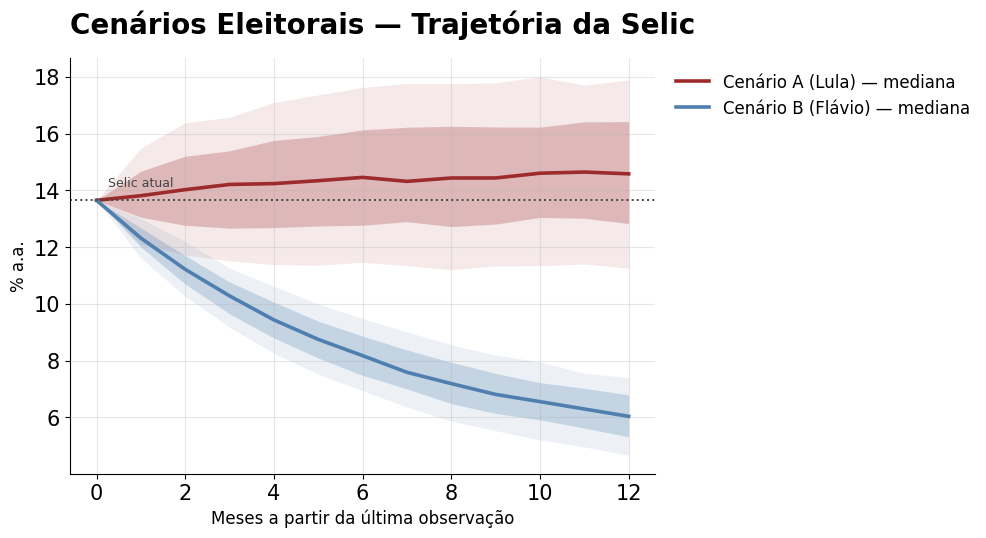

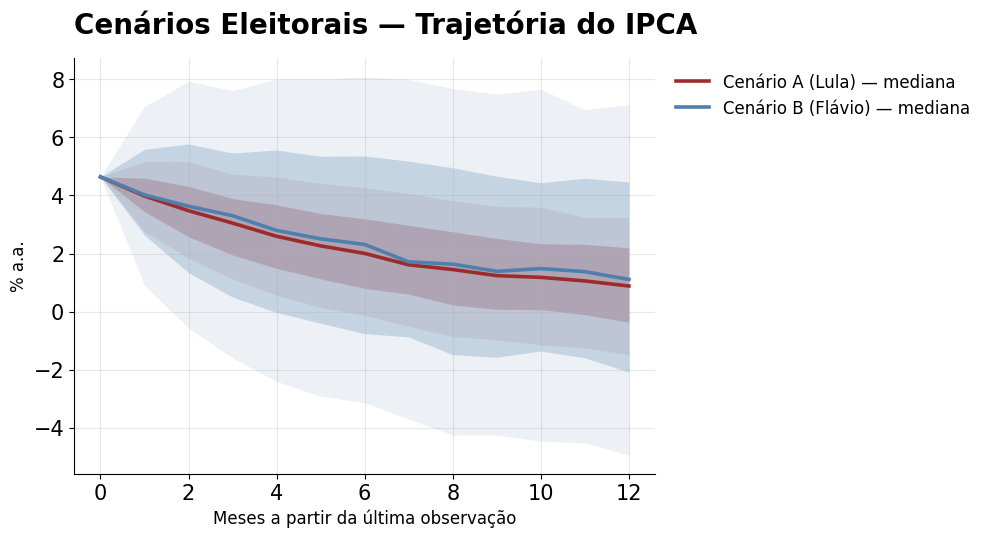

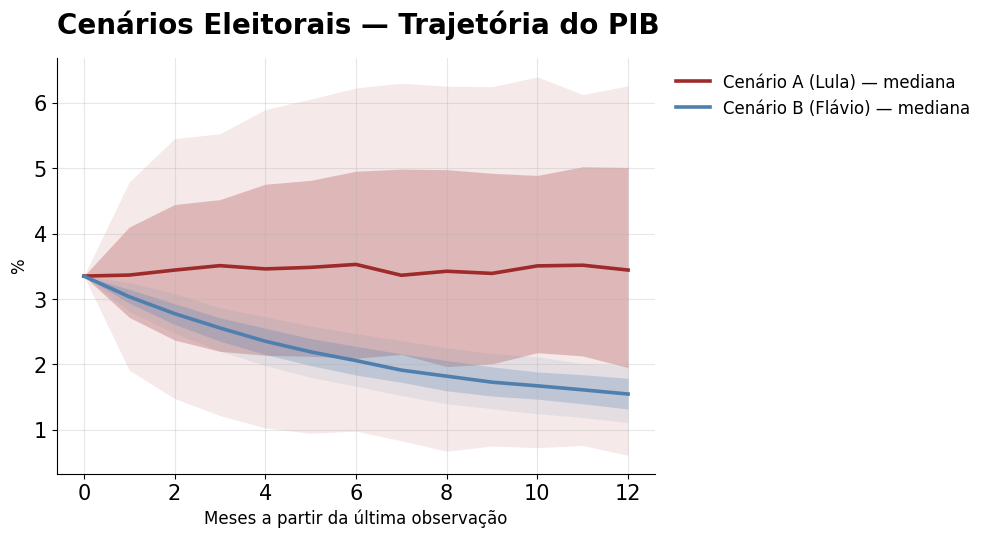


✔  Gráficos salvos — padrão executivo (sem set_position absoluto, legenda externa).


In [51]:
# ══════════════════════════════════════════════════════════════════════════════
#  BLOCO 5 — Fan charts eleitorais
# ══════════════════════════════════════════════════════════════════════════════

cores_cenario = {"Cenario_A_Lula": cores[3], "Cenario_B_Flavio": cores[2]}

def plotar_fan_chart(var_nome, titulo, unidade, linha_referencia=None, ref_label=None):
    fig, ax = plt.subplots(figsize=(10, 5.5))
    meses = np.arange(0, N_MESES + 1)

    for cenario, dados in resultados_simulacao.items():
        traj = dados[var_nome]
        mediana = np.median(traj, axis=0)
        p10, p90 = np.percentile(traj, [10, 90], axis=0)
        p25, p75 = np.percentile(traj, [25, 75], axis=0)
        cor = cores_cenario[cenario]
        label = "Cenário A (Lula)" if "A_Lula" in cenario else "Cenário B (Flávio)"

        ax.plot(meses, mediana, color=cor, linewidth=2.6, label=f"{label} — mediana")
        ax.fill_between(meses, p25, p75, alpha=0.25, color=cor, linewidth=0)
        ax.fill_between(meses, p10, p90, alpha=0.10, color=cor, linewidth=0)

    # Linha de referência (ex.: último valor observado) — essencial para o
    # leitor perceber se a trajetória parte de um nível realista

    if linha_referencia is not None:
        ax.axhline(linha_referencia, color="#444444", linestyle=":", linewidth=1.4)
        ax.annotate(ref_label or f"Último observado: {linha_referencia:.2f}",
                    xy=(0, linha_referencia),
                    xytext=(8, 8), textcoords="offset points",   # <- única mudança
                    fontsize=9, color="#444444", va="bottom")

    ax.set_title(titulo, loc="left")
    ax.set_xlabel("Meses a partir da última observação")
    ax.set_ylabel(unidade)
    ax.legend(loc="upper left", frameon=False, bbox_to_anchor=(1.01, 1.0))
    ax.spines[["top", "right"]].set_visible(False)

    # substitui set_position(proporcao) por layout automático com margem
    fig.tight_layout()
    plt.savefig(f"cenario_{var_nome}.png", dpi=300, bbox_inches="tight")
    plt.show()

# Selic com linha de referência no último nível observado real
plotar_fan_chart(
    "selic", "Cenários Eleitorais — Trajetória da Selic", "% a.a.",
    linha_referencia=df_periodo_B["selic"].dropna().iloc[-1],
    ref_label="Selic atual"
)
plotar_fan_chart("ipca", "Cenários Eleitorais — Trajetória do IPCA ", "% a.a.")
plotar_fan_chart("pib", "Cenários Eleitorais — Trajetória do PIB ", "%")

print("\n✔  Gráficos salvos — padrão executivo (sem set_position absoluto, legenda externa).")

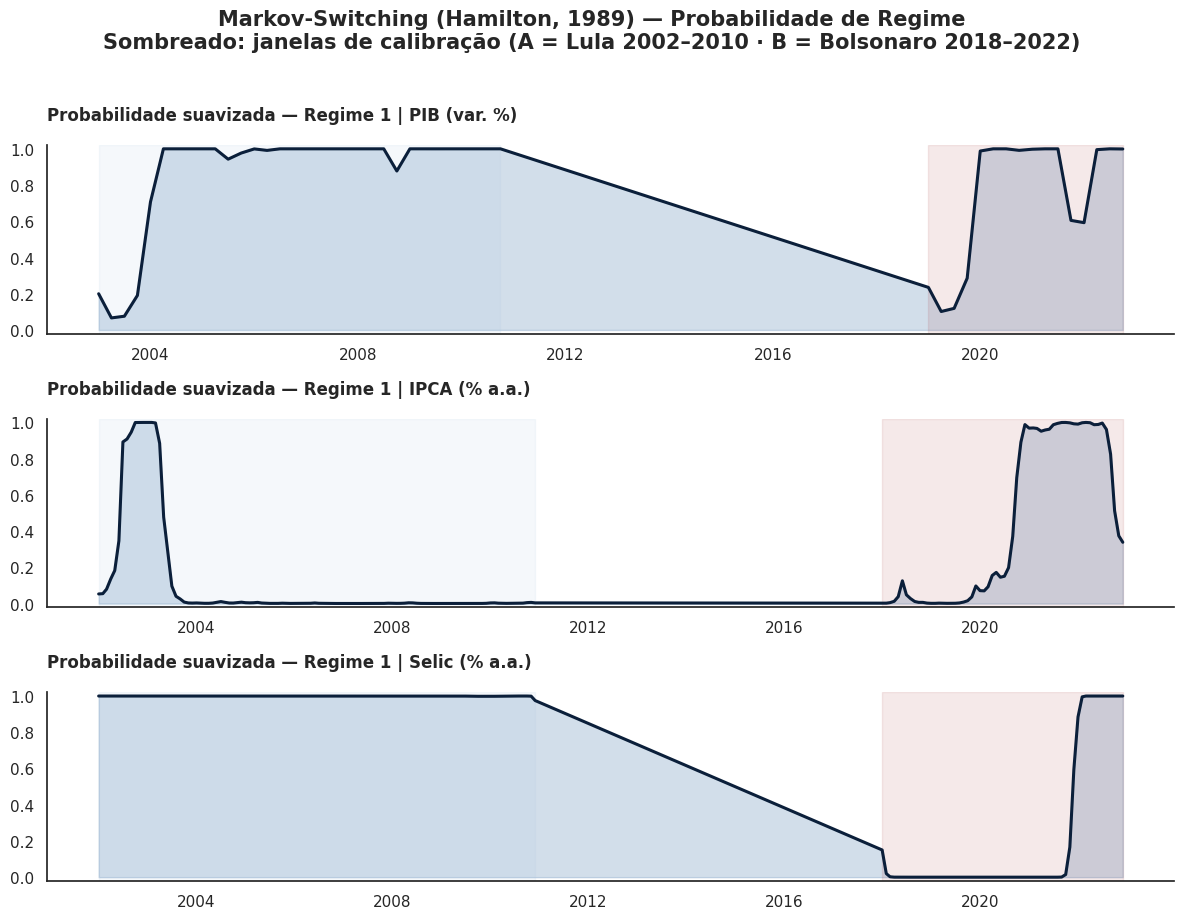

In [55]:
# ══════════════════════════════════════════════════════════════════════════════
#  Bloco 6 —  GRÁFICO: PROBABILIDADE DE REGIME MARKOV-SWITCHING.
# ══════════════════════════════════════════════════════════════════════════════
labels_var = {"pib_var": "PIB (var. %)", "ipca": "IPCA (% a.a.)", "selic": "Selic (% a.a.)"}

fig, axes = plt.subplots(len(labels_var), 1, figsize=(12, 9))

for ax, var in zip(axes, labels_var):
    serie_A = df_A_arc[var].dropna()
    serie_B = df_B_arc[var].dropna()
    serie_completa = pd.concat([serie_A, serie_B]).dropna()

    modelo_ms = MarkovRegression(
        serie_completa, k_regimes=2, trend="c", switching_variance=True
    ).fit(disp=False)

    prob_regime1 = modelo_ms.smoothed_marginal_probabilities[1]

    ax.plot(prob_regime1.index, prob_regime1.values, color=cores[0], lw=2.2)
    ax.fill_between(prob_regime1.index, 0, prob_regime1.values, color=cores[2], alpha=0.25)
    ax.axvspan(serie_A.index.min(), serie_A.index.max(), color=cores[1], alpha=0.12)
    ax.axvspan(serie_B.index.min(), serie_B.index.max(), color=cores[3], alpha=0.10)
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(f"Probabilidade suavizada — Regime 1 | {labels_var[var]}",
                 loc="left", fontsize=12, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Markov-Switching (Hamilton, 1989) — Probabilidade de Regime\n"
              "Sombreado: janelas de calibração (A = Lula 2002–2010 · B = Bolsonaro 2018–2022)",
              fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("markov_probabilidade_regime.png", dpi=300, bbox_inches="tight")
plt.show()

# MÓDULO 2 — FLUXO DE CAPITAIS ESTRANGEIROS

In [28]:
# ══════════════════════════════════════════════════════════════════════════════
#  CÉLULA 0 — Coleta
# ══════════════════════════════════════════════════════════════════════════════
DATA_INICIO_FLUXO = "2018-01-01"

df_fluxo = sgs.get({
    "portfolio_passivos" : 22902,
}, start=DATA_INICIO_FLUXO)

serie_pp = df_fluxo["portfolio_passivos"].dropna().copy()
# Correção: Primeiro transformamos o índice em Datetime, depois aplicamos asfreq na série
serie_pp.index = pd.to_datetime(serie_pp.index)
serie_pp = serie_pp.asfreq("MS")

print(f"✔  Série coletada: {len(serie_pp)} obs.")

✔  Série coletada: 101 obs.


In [29]:
# ══════════════════════════════════════════════════════════════════════════════
#  CÉLULA 1 — Estimação SARIMA
# ══════════════════════════════════════════════════════════════════════════════

ORDEM_SARIMA, ORDEM_SAZONAL = (0, 0, 1), (1, 0, 0, 12)

modelo_final_sarima = SARIMAX(
    serie_pp, order=ORDEM_SARIMA, seasonal_order=ORDEM_SAZONAL,
    trend="c", enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)

lb_fluxo = acorr_ljungbox(modelo_final_sarima.resid, lags=[6, 12], return_df=True)
print(f"✔  SARIMA{ORDEM_SARIMA}{ORDEM_SAZONAL} | Ljung-Box p_min={lb_fluxo['lb_pvalue'].min():.4f}")
print(f"✔  R² OOS validado previamente: 0.22 (positivo)")

✔  SARIMA(0, 0, 1)(1, 0, 0, 12) | Ljung-Box p_min=0.7304
✔  R² OOS validado previamente: 0.22 (positivo)


In [30]:
# ══════════════════════════════════════════════════════════════════════════════
#  CÉLULA 2 — Previsão 6 meses
# ══════════════════════════════════════════════════════════════════════════════
forecast_fluxo_final = modelo_final_sarima.get_forecast(steps=6)
fluxo_projetado = forecast_fluxo_final.predicted_mean
ic_fluxo_final  = forecast_fluxo_final.conf_int(alpha=0.05)

print("  Fluxo de portfólio projetado (6 meses):")
print(fluxo_projetado.round(2).to_string())

print(f"\n  ⚠️  NOTA: fluxo tratado como EXÓGENO ao sistema Desenrola/Eleições.")
print(f"     Equação ponte testada e descartada (Granger não significativo,")
print(f"     R²≤0.03 em todas as especificações) — ver Etapa 1.")

  Fluxo de portfólio projetado (6 meses):
2026-06-01    -12.96
2026-07-01    319.37
2026-08-01    409.29
2026-09-01    257.75
2026-10-01    228.99
2026-11-01    357.06
Freq: MS

  ⚠️  NOTA: fluxo tratado como EXÓGENO ao sistema Desenrola/Eleições.
     Equação ponte testada e descartada (Granger não significativo,
     R²≤0.03 em todas as especificações) — ver Etapa 1.


In [31]:
# resíduos do SARIMA já ajustado (modelo_final_sarima)
res = modelo_final_sarima.resid.dropna()

garch = arch_model(res, mean="Zero", vol="Garch", p=1, q=1, dist="normal").fit(disp="off")

print(f"SARIMA  -> AIC={modelo_final_sarima.aic:.2f}  BIC={modelo_final_sarima.bic:.2f}")
print(f"GARCH11 -> AIC={garch.aic:.2f}  BIC={garch.bic:.2f}")

SARIMA  -> AIC=1477.46  BIC=1487.41
GARCH11 -> AIC=1674.04  BIC=1681.88


In [32]:
# ══════════════════════════════════════════════════════════════════════════════
#  CÉLULA 3— Diagnóstico de heterocedasticidade (ARCH-LM)
# ══════════════════════════════════════════════════════════════════════════════
from statsmodels.stats.diagnostic import het_arch

resid_sarima = modelo_final_sarima.resid.dropna()
arch_test = het_arch(resid_sarima, nlags=12)

print(f"  Teste ARCH-LM (H0: sem heterocedasticidade condicional):")
print(f"  Estatística: {arch_test[0]:.4f} | p-valor: {arch_test[1]:.4f} "
      f"{'✅ GARCH justificado' if arch_test[1] < 0.10 else '⚠️  GARCH não claramente necessário'}")

  Teste ARCH-LM (H0: sem heterocedasticidade condicional):
  Estatística: 5.8039 | p-valor: 0.9256 ⚠️  GARCH não claramente necessário


In [33]:
# ══════════════════════════════════════════════════════════════════════════════
#  CÉLULA 4 — Grid search: melhor especificação GARCH sobre os resíduos do SARIMA
# ══════════════════════════════════════════════════════════════════════════════
!pip install arch -q
from arch import arch_model

resid_scaled = resid_sarima / 100

# ── Grid: ordem GARCH(p,q), distribuição e tipo de volatilidade ──────────────
especificacoes = [
    {"vol": "GARCH", "p": 1, "q": 1, "dist": "normal"},
    {"vol": "GARCH", "p": 1, "q": 1, "dist": "t"},
    {"vol": "GARCH", "p": 1, "q": 1, "dist": "skewt"},
    {"vol": "GARCH", "p": 2, "q": 1, "dist": "t"},
    {"vol": "GARCH", "p": 1, "q": 2, "dist": "t"},
    {"vol": "EGARCH", "p": 1, "q": 1, "dist": "t"},     # assimetria (leverage effect)
    {"vol": "GJR-GARCH", "p": 1, "o": 1, "q": 1, "dist": "t"},  # assimetria explícita
]

resultados_garch = []
for spec in especificacoes:
    try:
        kwargs = {k: v for k, v in spec.items() if k != "dist"}
        modelo = arch_model(resid_scaled, mean="Zero", dist=spec["dist"], **kwargs)
        res = modelo.fit(disp="off")
        resultados_garch.append({
            "especificacao": f"{spec['vol']}({spec.get('p',1)},{spec.get('q',1)})-{spec['dist']}",
            "AIC": res.aic, "BIC": res.bic, "LogLik": res.loglikelihood,
            "modelo": res
        })
    except Exception as e:
        print(f"  ⚠️  {spec} falhou: {e}")

df_garch_grid = pd.DataFrame(resultados_garch).sort_values("BIC")
print("  Grid de especificações GARCH (ordenado por BIC):")
print(df_garch_grid[["especificacao", "AIC", "BIC", "LogLik"]].round(2).to_string(index=False))

melhor_spec = df_garch_grid.iloc[0]
res_garch = melhor_spec["modelo"]
print(f"\n✔  Melhor especificação: {melhor_spec['especificacao']} (BIC={melhor_spec['BIC']:.2f})")

alpha1 = res_garch.params.get("alpha[1]", np.nan)
beta1  = res_garch.params.get("beta[1]", np.nan)
persistencia = alpha1 + beta1 if not np.isnan(beta1) else alpha1

print(f"  Persistência (α+β): {persistencia:.4f} "
      f"{'✅ estacionária' if persistencia < 1 else '⚠️  não estacionária'}")

  ⚠️  {'vol': 'GJR-GARCH', 'p': 1, 'o': 1, 'q': 1, 'dist': 't'} falhou: Unknown model type in vol
  Grid de especificações GARCH (ordenado por BIC):
    especificacao    AIC    BIC  LogLik
    EGARCH(1,1)-t 734.64 745.10 -363.32
     GARCH(1,1)-t 736.45 746.91 -364.23
     GARCH(1,2)-t 735.89 748.96 -362.94
 GARCH(1,1)-skewt 738.13 751.21 -364.07
     GARCH(2,1)-t 738.45 751.53 -364.23
GARCH(1,1)-normal 743.79 751.64 -368.90

✔  Melhor especificação: EGARCH(1,1)-t (BIC=745.10)
  Persistência (α+β): 0.7572 ✅ estacionária


In [34]:
# ══════════════════════════════════════════════════════════════════════════════
#  CÉLULA 5 — Forecast via simulação
# ══════════════════════════════════════════════════════════════════════════════
media_projetada = fluxo_projetado

# EGARCH exige simulação para horizonte > 1 (sem forma fechada analítica)
forecast_vol = res_garch.forecast(
    horizon=6, method="simulation", simulations=1000, reindex=False
)
vol_projetada = np.sqrt(forecast_vol.variance.values[-1]) * 100

ic_dinamico_lower = media_projetada.values - 1.96 * vol_projetada
ic_dinamico_upper = media_projetada.values + 1.96 * vol_projetada

df_sarima_garch = pd.DataFrame({
    "media_sarima": media_projetada.values,
    "vol_garch": vol_projetada,
    "ic_lower_dinamico": ic_dinamico_lower,
    "ic_upper_dinamico": ic_dinamico_upper,
}, index=media_projetada.index)

print(f"  Projeção SARIMA-GARCH ({melhor_spec['especificacao']}):")
print(df_sarima_garch.round(2).to_string())

  Projeção SARIMA-GARCH (EGARCH(1,1)-t):
            media_sarima  vol_garch  ic_lower_dinamico  ic_upper_dinamico
2026-06-01        -12.96    1045.17           -2061.49            2035.56
2026-07-01        319.37    1029.85           -1699.14            2337.87
2026-08-01        409.29    1013.68           -1577.52            2396.10
2026-09-01        257.75    1002.64           -1707.42            2222.92
2026-10-01        228.99     994.72           -1720.66            2178.63
2026-11-01        357.06    1022.01           -1646.08            2360.21


In [35]:
# ══════════════════════════════════════════════════════════════════════════════
#  CÉLULA 6 — Setup visual
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.font_manager as fm
from matplotlib.font_manager import FontProperties

# Tenta carregar Montserrat; usa fallback sans-serif se indisponível no Colab
try:
    font_path = "/usr/share/fonts/truetype/montserrat/Montserrat-Regular.ttf"
    fm.fontManager.addfont(font_path)
    font_name = FontProperties(fname=font_path).get_name()
except Exception:
    font_name = "DejaVu Sans"
    print("  ⚠️  Montserrat não encontrada — usando fonte padrão")

PROPORCAO = [0, 0, 0.8, 0.8]

CORES_CORPORATIVAS = [
    "#0B1F3A", "#AFCBE3", "#4F7FAE", "#9E2B2B", "#8A6F3D",
    "#2E4A3F", "#C46013", "#EDC948", "#C2B280", "#C51700",
]

plt.rcParams.update({
    "font.family": font_name,
    "font.sans-serif": [font_name],
    "font.size": 10.5,
    "figure.figsize": (8, 5),
    "axes.titlesize": 20,
    "axes.titleweight": "bold",
    "axes.titlepad": 18,
    "axes.labelsize": 12,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 12,
    "legend.title_fontsize": 12,
    "lines.linewidth": 2.8,
    "lines.markersize": 4,
    "axes.grid": True,
    "grid.alpha": 0.3,
})
print("✔  Estilo corporativo aplicado (Montserrat + paleta navy/burgundy)")

  ⚠️  Montserrat não encontrada — usando fonte padrão
✔  Estilo corporativo aplicado (Montserrat + paleta navy/burgundy)


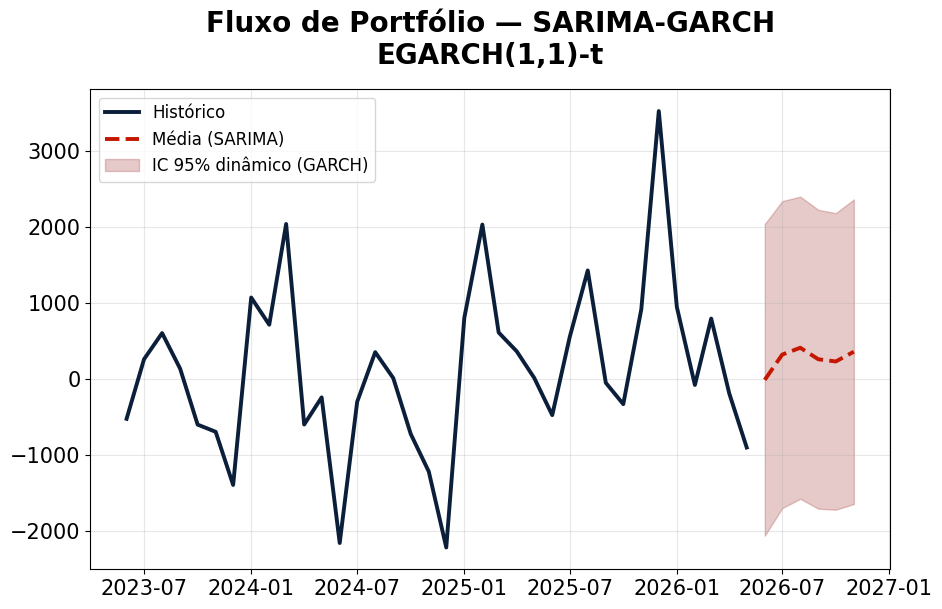

✔  Gráfico salvo no padrão corporativo — melhor especificação: EGARCH(1,1)-t


In [36]:
# ══════════════════════════════════════════════════════════════════════════════
#  CÉLULA 7 — Gráfico final na formatação do arquivo de referência
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 6))

hist = serie_pp.tail(36)
ax.plot(hist.index, hist.values, color=CORES_CORPORATIVAS[0], label="Histórico")
ax.plot(media_projetada.index, media_projetada.values, color=CORES_CORPORATIVAS[9],
        linestyle="--", label="Média (SARIMA)")

ax.fill_between(media_projetada.index, ic_dinamico_lower, ic_dinamico_upper,
                alpha=0.25, color=CORES_CORPORATIVAS[3], label="IC 95% dinâmico (GARCH)")

ax.set_title(f"Fluxo de Portfólio — SARIMA-GARCH\n{melhor_spec['especificacao']}")
ax.set_xlabel("")
ax.legend()
ax.set_position(PROPORCAO)

plt.savefig("sarima_garch_fluxo_corporativo.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"✔  Gráfico salvo no padrão corporativo — melhor especificação: {melhor_spec['especificacao']}")

# MÓDULO 3 — MODELAGEM IBOVESPA

In [37]:
# ══════════════════════════════════════════════════════════════════════════════
#  BLOCO 1 — Painel com S&P500 como controle de risco sistêmico global
# ══════════════════════════════════════════════════════════════════════════════
# Adiciona ret_sp500 (Reis, Meurer & Da Silva, 2010) — variável omitida que
# provavelmente explica o baixo R² da especificação anterior.

import yfinance as yf
import statsmodels.api as sm

# ── 1) Ibovespa (log-retorno mensal, %) ───────────────────────────────────────
ibov = yf.download("^BVSP", start="2018-01-01", interval="1mo", progress=False)["Close"].dropna()
ibov.index = ibov.index.to_period("M").to_timestamp("M")
ret_ibov = (np.log(ibov / ibov.shift(1)) * 100).dropna()
ret_ibov.name = "ret_ibov"

# ── 2) S&P500 — proxy de risco sistêmico global (NOVO) ────────────────────────
sp500 = yf.download("^GSPC", start="2018-01-01", interval="1mo", progress=False)["Close"].dropna()
sp500.index = sp500.index.to_period("M").to_timestamp("M")
ret_sp500 = (np.log(sp500 / sp500.shift(1)) * 100).dropna()
ret_sp500.name = "ret_sp500"

# ── 3) Juro real histórico ─────────────────────────────────────────────────────
juros_hist = sgs.get({"selic": 432, "ipca": 433}, start="2018-01-01")
juros_hist.index = pd.to_datetime(juros_hist.index).to_period("M").to_timestamp("M")
juros_hist["juro_real"] = ((1 + juros_hist["selic"]/100) / (1 + juros_hist["ipca"]/100) - 1) * 100

# ── 4) Fluxo padronizado (choque z-score) ─────────────────────────────────────
fluxo_hist = serie_pp.copy()
fluxo_hist.index = fluxo_hist.index.to_period("M").to_timestamp("M")
fluxo_mu, fluxo_sd = fluxo_hist.mean(), fluxo_hist.std()
fluxo_z = (fluxo_hist - fluxo_mu) / fluxo_sd
fluxo_z.name = "fluxo_z"

# ── 5) Painel único + dummies eleitorais ──────────────────────────────────────
painel = pd.concat([ret_ibov, ret_sp500, juros_hist["juro_real"], fluxo_z], axis=1).dropna()
painel = construir_dummies_eleitorais(painel, ["2018-10-28", "2022-10-30"], janela_meses=12)

if "^BVSP" in painel.columns:
    painel = painel.rename(columns={"^BVSP": "ret_ibov"})

print(f"✔  Painel construído — {len(painel)} observações mensais")
print(f"   Período: {painel.index[0]:%Y-%m} a {painel.index[-1]:%Y-%m}")

✔  Painel construído — 100 observações mensais
   Período: 2018-02 a 2026-05


In [38]:
# ══════════════════════════════════════════════════════════════════════════════
#  BLOCO 2 — Regressão frequentista: com vs. sem S&P500
# ══════════════════════════════════════════════════════════════════════════════

X_cols_v1 = ["juro_real", "fluxo_z", "D_eleitoral", "D_pos_eleitoral"]
X_cols_v2 = ["juro_real", "fluxo_z", "^GSPC", "D_eleitoral", "D_pos_eleitoral"]

X_v1 = sm.add_constant(painel[X_cols_v1])
X_v2 = sm.add_constant(painel[X_cols_v2])
y = painel["ret_ibov"]

modelo_ibov_v1 = sm.OLS(y, X_v1).fit(cov_type="HAC", cov_kwds={"maxlags": 3})
modelo_ibov_v2 = sm.OLS(y, X_v2).fit(cov_type="HAC", cov_kwds={"maxlags": 3})

print(f"  R² v1 (sem S&P500): {modelo_ibov_v1.rsquared:.4f}  R²adj: {modelo_ibov_v1.rsquared_adj:.4f}")
print(f"  R² v2 (com S&P500) : {modelo_ibov_v2.rsquared:.4f}  R²adj: {modelo_ibov_v2.rsquared_adj:.4f}")
print()
print(modelo_ibov_v2.summary())

# Usa v2 daqui em diante se S&P500 melhorar significativamente o ajuste
USAR_V2 = modelo_ibov_v2.rsquared_adj > modelo_ibov_v1.rsquared_adj
modelo_ibov = modelo_ibov_v2 if USAR_V2 else modelo_ibov_v1
X_cols_final = X_cols_v2 if USAR_V2 else X_cols_v1
print(f"\n✔  Especificação adotada: {'v2 (com S&P500)' if USAR_V2 else 'v1 (original)'}")

  R² v1 (sem S&P500): 0.0117  R²adj: -0.0299
  R² v2 (com S&P500) : 0.2262  R²adj: 0.1850

                            OLS Regression Results                            
Dep. Variable:               ret_ibov   R-squared:                       0.226
Model:                            OLS   Adj. R-squared:                  0.185
Method:                 Least Squares   F-statistic:                     1.874
Date:                Fri, 10 Jul 2026   Prob (F-statistic):              0.106
Time:                        21:48:49   Log-Likelihood:                -314.67
No. Observations:                 100   AIC:                             641.3
Df Residuals:                      94   BIC:                             657.0
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------

In [39]:
# ══════════════════════════════════════════════════════════════════════════════
#  BLOCO 3 — Regressão Bayesiana (Normal-Inverse-Gamma) com prior ancorado
# ══════════════════════════════════════════════════════════════════════════════
# Priors: Gordon (juro_real<0), Reis/Meurer/Da Silva (fluxo>0),
# risco sistêmico global (S&P500>0, beta≈1 — mercado emergente amplifica EUA)

X_mat, y_vec = X_cols_final, y.values
X_full = sm.add_constant(painel[X_cols_final]).values

if USAR_V2:
    mu0 = np.array([0.0, -0.30, 0.30, 1.0, 0.0, 0.0])
    Sigma0 = np.diag([25.0, 1.0, 1.0, 0.5, 4.0, 4.0])
else:
    mu0 = np.array([0.0, -0.30, 0.30, 0.0, 0.0])
    Sigma0 = np.diag([25.0, 1.0, 1.0, 4.0, 4.0])

a0, b0 = 3.0, 10.0
n, k = X_full.shape

Sigma0_inv = np.linalg.inv(Sigma0)
Sigma_n = np.linalg.inv(Sigma0_inv + X_full.T @ X_full)
mu_n = Sigma_n @ (Sigma0_inv @ mu0 + X_full.T @ y_vec)
a_n = a0 + n/2
b_n = b0 + 0.5*(y_vec @ y_vec + mu0 @ Sigma0_inv @ mu0 - mu_n @ np.linalg.inv(Sigma_n) @ mu_n)

np.random.seed(42)
N_POST = 4000
sigma2_draws = 1 / np.random.gamma(a_n, 1/b_n, size=N_POST)
beta_draws = np.array([np.random.multivariate_normal(mu_n, s2*Sigma_n) for s2 in sigma2_draws])

coef_bayes = pd.DataFrame(beta_draws, columns=["const"]+X_cols_final)
print("Posterior dos coeficientes (média | IC90%):")
print(coef_bayes.describe(percentiles=[0.05, 0.95]).T[["mean","5%","95%"]].round(4))

Posterior dos coeficientes (média | IC90%):
                   mean      5%     95%
const           -0.8097 -2.9990  1.4095
juro_real        0.0707 -0.1364  0.2795
fluxo_z          0.2734 -0.6523  1.1994
^GSPC            0.6426  0.4487  0.8459
D_eleitoral      0.2819 -2.0854  2.6431
D_pos_eleitoral  0.9472 -1.3133  3.1213


In [40]:
import numpy as np
# ══════════════════════════════════════════════════════════════════════════════
#  BLOCO 4 — Projeção do S&P500 futuro (random walk com drift histórico)
# ══════════════════════════════════════════════════════════════════════════════
# Necessário só se USAR_V2=True — projeta S&P500 para os 12 meses do horizonte,
# usando drift histórico (sem tentar prever choques específicos do mercado americano).

N_HORIZ = 12
datas_ibov = pd.date_range(painel.index[-1] + pd.offsets.MonthEnd(1), periods=N_HORIZ, freq="ME")

# Calculate drift and volatility from historical S&P500 returns
drift_sp500 = pd.Series(ret_sp500.mean())
vol_sp500 = pd.Series(ret_sp500.std())

if USAR_V2:
    drift_sp500_val = drift_sp500.iloc[0]
    vol_sp500_val = vol_sp500.iloc[0]
    ret_sp500_fcst = np.random.normal(drift_sp500_val, vol_sp500_val, size=(4000, N_HORIZ))
    print(f"✔  S&P500 projetado via random walk c/ drift: μ={drift_sp500_val:.3f}% σ={vol_sp500_val:.3f}%")

✔  S&P500 projetado via random walk c/ drift: μ=0.967% σ=4.754%


In [41]:
# ══════════════════════════════════════════════════════════════════════════════
#  BLOCO 5 — Projeção do Ibovespa por cenário (integra S&P500 se v2)
# ══════════════════════════════════════════════════════════════════════════════

fluxo_fcst = np.concatenate([media_projetada.values, np.full(N_HORIZ - len(media_projetada), fluxo_mu)])
fluxo_fcst_z = (fluxo_fcst - fluxo_mu) / fluxo_sd

data_eleicao_2026 = pd.Timestamp("2026-10-04")
D_elei_fcst = ((datas_ibov <= data_eleicao_2026) &
               (datas_ibov >= data_eleicao_2026 - pd.DateOffset(months=12))).astype(int)
D_pos_fcst = (datas_ibov > data_eleicao_2026).astype(int)

base_ibc = CONDICOES_INICIAIS_6X1["ibc_br_2026"]
choque_6x1_pct = (trajetorias_6x1["rho_1.0_cobbdouglas"].values - base_ibc) / base_ibc * 100
LAMBDA_MARGEM = 1.5

resid_pool = modelo_ibov.resid.values
N_SIM = 4000

resultado_ibov_bayes = {}
for cenario, dados in resultados_simulacao.items():
    selic_traj = np.median(dados["selic"], axis=0)[1:N_HORIZ+1]
    ipca_traj = np.median(dados["ipca"], axis=0)[1:N_HORIZ+1]
    juro_real_traj = ((1+selic_traj/100)/(1+ipca_traj/100) - 1) * 100
    ret_6x1 = (LAMBDA_MARGEM * choque_6x1_pct) / N_HORIZ

    if USAR_V2:
        X_fcst_mean = np.column_stack([
            np.ones(N_HORIZ), juro_real_traj, fluxo_fcst_z,
            ret_sp500_fcst.mean(axis=0), D_elei_fcst, D_pos_fcst
        ])
    else:
        X_fcst_mean = np.column_stack([
            np.ones(N_HORIZ), juro_real_traj, fluxo_fcst_z, D_elei_fcst, D_pos_fcst
        ])

    idx_beta = np.random.randint(0, N_POST, N_SIM)
    choques = np.random.choice(resid_pool, size=(N_SIM, N_HORIZ), replace=True)

    ret_sim = beta_draws[idx_beta] @ X_fcst_mean.T + ret_6x1 + choques
    trajetorias = float(ibov.iloc[-1]) * np.cumprod(1 + ret_sim/100, axis=1)

    resultado_ibov_bayes[cenario] = {
        "mediana": np.median(trajetorias, axis=0),
        "p10": np.percentile(trajetorias, 10, axis=0),
        "p90": np.percentile(trajetorias, 90, axis=0),
    }

print("  Ibovespa projetado (12 meses, mediana):")
for cenario, r in resultado_ibov_bayes.items():
    print(f"\n  {cenario}: {r['mediana'][-1]:.0f} pontos (mês 12)")

  Ibovespa projetado (12 meses, mediana):

  Cenario_A_Lula: 201698 pontos (mês 12)

  Cenario_B_Flavio: 192016 pontos (mês 12)


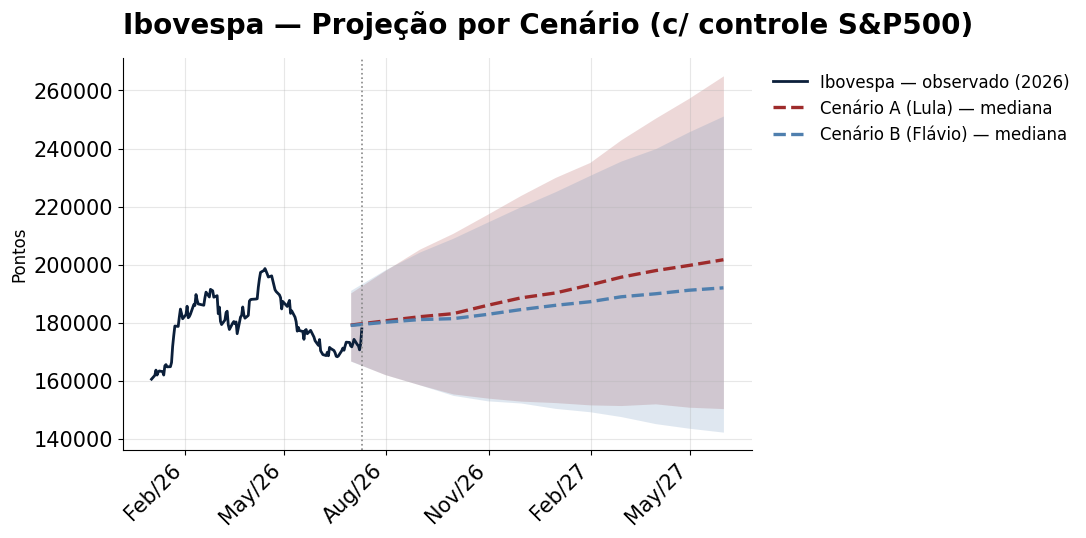

In [42]:
# ══════════════════════════════════════════════════════════════════════════════
#  BLOCO 6 — Gráfico Ibovespa: histórico 2026 + cenários
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.dates as mdates

ibov_2026 = yf.download("^BVSP", start="2026-01-01", interval="1d", progress=False)["Close"].dropna()
ibov_2026.index = pd.to_datetime(ibov_2026.index)

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(ibov_2026.index, ibov_2026.values, color=CORES_CORPORATIVAS[0],
        linewidth=2.0, label="Ibovespa — observado (2026)")

for cenario, r in resultado_ibov_bayes.items():
    cor = cores_cenario[cenario]
    label = "Cenário A (Lula)" if "A_Lula" in cenario else "Cenário B (Flávio)"
    ax.plot(datas_ibov, r["mediana"], color=cor, linewidth=2.4, linestyle="--", label=f"{label} — mediana")
    ax.fill_between(datas_ibov, r["p10"], r["p90"], alpha=0.18, color=cor, linewidth=0)

ax.axvline(ibov_2026.index[-1], color="#888888", linestyle=":", linewidth=1.2)
ax.set_title(f"Ibovespa — Projeção por Cenário {'(c/ controle S&P500)' if USAR_V2 else ''}", loc="left")
ax.set_ylabel("Pontos")
ax.legend(loc="upper left", frameon=False, bbox_to_anchor=(1.01, 1.0))
ax.spines[["top","right"]].set_visible(False)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%y"))
fig.autofmt_xdate(rotation=45, ha="right")

fig.tight_layout()
plt.savefig("ibovespa_cenarios_2026_v2.png", dpi=300, bbox_inches="tight")
plt.show()

# MÓDULO 4 — ECONOMIA DOMÉSTICA: PIB E DESEMPREGO

In [43]:
import yfinance as yf

# ══════════════════════════════════════════════════════════════════════════════
#  BLOCO 1 — Painel doméstico (PIB + Desemprego + IPCA) + Ibovespa histórico
# ══════════════════════════════════════════════════════════════════════════════
desemprego_hist = sgs.get({"taxa_desocupacao": 24369}, start="2018-01-01")
desemprego_hist.index = pd.to_datetime(desemprego_hist.index).to_period("M").to_timestamp("M")

# g_pib: variação % mensal do IBC-Br (proxy PIB)
g_pib = df_dessaz["pib_ibc_br"].pct_change().dropna() * 100
g_pib.index = pd.to_datetime(g_pib.index).to_period("M").to_timestamp("M") # Standardize to EOM
g_pib.name = "g_pib"

# Ensure df_dessaz["ipca_12m"] also has end-of-month index
ipca_12m_eom = df_dessaz["ipca_12m"].rename("ipca_12m")
ipca_12m_eom.index = pd.to_datetime(ipca_12m_eom.index).to_period("M").to_timestamp("M") # Standardize to EOM

painel_real = pd.concat([
    g_pib,
    ipca_12m_eom,  # Use the EOM version
    desemprego_hist["taxa_desocupacao"],
    ret_ibov,  # reaproveitado do Bloco 8 (Etapa 2)
], axis=1).dropna()

# Rename the Ibovespa column from '^BVSP' to 'ret_ibov'
painel_real = painel_real.rename(columns={'^BVSP': 'ret_ibov'})

painel_real["d_desemprego"] = painel_real["taxa_desocupacao"].diff()
painel_real = painel_real.dropna()
print(f"✔  Painel doméstico: {len(painel_real)} observações mensais "
      f"({painel_real.index[0]:%Y-%m} a {painel_real.index[-1]:%Y-%m})")

✔  Painel doméstico: 99 observações mensais (2018-03 a 2026-05)


In [44]:
# ══════════════════════════════════════════════════════════════════════════════
#  BLOCO 2 — ARDL(2,2): PIB (IBC-Br) em função do Ibovespa defasado + IPCA
# ══════════════════════════════════════════════════════════════════════════════
painel_ardl = painel_real.copy()
for lag in (1, 2):
    painel_ardl[f"g_pib_L{lag}"]    = painel_ardl["g_pib"].shift(lag)
    painel_ardl[f"ret_ibov_L{lag}"] = painel_ardl["ret_ibov"].shift(lag)
painel_ardl["ipca_L1"] = painel_ardl["ipca_12m"].shift(1)
painel_ardl = painel_ardl.dropna()

X_ardl = sm.add_constant(painel_ardl[[
    "g_pib_L1", "g_pib_L2", "ret_ibov", "ret_ibov_L1", "ret_ibov_L2",
    "ipca_12m", "ipca_L1"
]])
y_ardl = painel_ardl["g_pib"]

modelo_ardl_pib = sm.OLS(y_ardl, X_ardl).fit(cov_type="HAC", cov_kwds={"maxlags": 3})
print(modelo_ardl_pib.summary())

resid_lb = acorr_ljungbox(modelo_ardl_pib.resid, lags=[6, 12], return_df=True)
print(f"\nLjung-Box p (lag6/lag12): {resid_lb['lb_pvalue'].iloc[0]:.4f} / {resid_lb['lb_pvalue'].iloc[1]:.4f}")

from statsmodels.stats.stattools import durbin_watson
print(f"Durbin-Watson: {durbin_watson(modelo_ardl_pib.resid):.3f}")

                            OLS Regression Results                            
Dep. Variable:                  g_pib   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.179
Method:                 Least Squares   F-statistic:                     6.624
Date:                Fri, 10 Jul 2026   Prob (F-statistic):           2.63e-06
Time:                        21:48:51   Log-Likelihood:                -254.72
No. Observations:                  97   AIC:                             525.4
Df Residuals:                      89   BIC:                             546.0
Df Model:                           7                                         
Covariance Type:                  HAC                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0624      0.846      0.074      

In [45]:
# ══════════════════════════════════════════════════════════════════════════════
#  BLOCO 3 — Okun dinâmico: ΔDesemprego_t = d0 + d1*g_pib_t + d2*g_pib_L1 + d3*ΔDesemprego_L1
#  Respecificação: componente autorregressivo para capturar persistência
# ══════════════════════════════════════════════════════════════════════════════
painel_okun = painel_real.copy()
painel_okun["g_pib_L1"]         = painel_okun["g_pib"].shift(1)
painel_okun["d_desemprego_L1"]  = painel_okun["d_desemprego"].shift(1)
painel_okun = painel_okun.dropna()

X_okun = sm.add_constant(painel_okun[["g_pib", "g_pib_L1", "d_desemprego_L1"]])
y_okun = painel_okun["d_desemprego"]

modelo_okun = sm.OLS(y_okun, X_okun).fit(cov_type="HAC", cov_kwds={"maxlags": 3})
print(modelo_okun.summary())
print(f"\nCoeficiente de Okun (contemporâneo): {modelo_okun.params['g_pib']:.4f} (p={modelo_okun.pvalues['g_pib']:.4f})")

resid_lb_okun = acorr_ljungbox(modelo_okun.resid, lags=[6, 12], return_df=True)
print(f"Ljung-Box p (lag6/lag12): {resid_lb_okun['lb_pvalue'].iloc[0]:.4f} / {resid_lb_okun['lb_pvalue'].iloc[1]:.4f}")
print(f"Durbin-Watson: {durbin_watson(modelo_okun.resid):.3f}")

for lags in [1, 2, 3, 6, 12]:
    lb = acorr_ljungbox(modelo_ardl_pib.resid, lags=[lags], return_df=True)
    print(f"ARDL  lag={lags:>2d}  p={lb['lb_pvalue'].iloc[0]:.4f}")

for lags in [1, 2, 3, 6, 12]:
    lb = acorr_ljungbox(modelo_okun.resid, lags=[lags], return_df=True)
    print(f"Okun  lag={lags:>2d}  p={lb['lb_pvalue'].iloc[0]:.4f}")

from statsmodels.tsa.stattools import acf

def acf_diagnostico(resid, nome, nlags=12):
    vals = acf(resid, nlags=nlags, fft=False)
    ic = 1.96 / np.sqrt(len(resid))
    print(f"\n{nome} (IC 95% = ±{ic:.4f})")
    for lag in range(1, nlags + 1):
        marca = " ⚠️" if abs(vals[lag]) > ic else ""
        print(f"  lag {lag:>2d}: {vals[lag]:+.4f}{marca}")

acf_diagnostico(modelo_ardl_pib.resid, "ARDL (PIB)")
acf_diagnostico(modelo_okun.resid, "Okun")

modelo_ardl_pib = sm.OLS(y_ardl, X_ardl).fit(cov_type="HAC", cov_kwds={"maxlags": 12})
print(modelo_ardl_pib.summary())

modelo_okun = sm.OLS(y_okun, X_okun).fit(cov_type="HAC", cov_kwds={"maxlags": 12})
print(modelo_okun.summary())

                            OLS Regression Results                            
Dep. Variable:           d_desemprego   R-squared:                       0.491
Model:                            OLS   Adj. R-squared:                  0.474
Method:                 Least Squares   F-statistic:                     41.18
Date:                Fri, 10 Jul 2026   Prob (F-statistic):           4.43e-17
Time:                        21:48:51   Log-Likelihood:                 12.370
No. Observations:                  98   AIC:                            -16.74
Df Residuals:                      94   BIC:                            -6.401
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.0238      0.023     

In [46]:
# ══════════════════════════════════════════════════════════════════════════════
#  BLOCO 4 — Projeção 12 meses: PIB via ARDL(2,2) + Desemprego via Okun dinâmico
# ══════════════════════════════════════════════════════════════════════════════
N_SIM_REAL = 4000
resid_pool_ardl = modelo_ardl_pib.resid.values
resid_pool_okun = modelo_okun.resid.values

beta_ardl_draws = np.random.multivariate_normal(
    modelo_ardl_pib.params.values, modelo_ardl_pib.cov_params().values, size=N_SIM_REAL)
beta_okun_draws = np.random.multivariate_normal(
    modelo_okun.params.values, modelo_okun.cov_params().values, size=N_SIM_REAL)

# Condições iniciais (2 lags de histórico necessários para ARDL(2,2))
g_pib_L1_0    = painel_ardl["g_pib"].iloc[-1]
g_pib_L2_0    = painel_ardl["g_pib"].iloc[-2]
ret_ibov_L1_0 = painel_ardl["ret_ibov"].iloc[-1]
ret_ibov_L2_0 = painel_ardl["ret_ibov"].iloc[-2]
ipca_L1_0     = painel_ardl["ipca_12m"].iloc[-1]
d_desemp_L1_0 = painel_real["d_desemprego"].iloc[-1]
desemp_nivel_0 = painel_real["taxa_desocupacao"].iloc[-1]

resultado_real = {}
for cenario in resultado_ibov_bayes:
    ibov_med = resultado_ibov_bayes[cenario]["mediana"]
    ret_ibov_cenario = np.diff(np.log(np.concatenate([[float(ibov.iloc[-1])], ibov_med]))) * 100
    ipca_cenario = np.median(resultados_simulacao[cenario]["ipca"], axis=0)[1:N_HORIZ + 1]

    # paths determinísticos com histórico prefixado (índices 0/1 = t-2/t-1)
    ret_ibov_path = np.concatenate([[ret_ibov_L2_0, ret_ibov_L1_0], ret_ibov_cenario])
    ipca_path     = np.concatenate([[ipca_L1_0], ipca_cenario])

    pib_sim    = np.zeros((N_SIM_REAL, N_HORIZ))
    desemp_sim = np.zeros((N_SIM_REAL, N_HORIZ))
    g_pib_path = np.zeros((N_SIM_REAL, N_HORIZ + 2))
    g_pib_path[:, 0] = g_pib_L2_0
    g_pib_path[:, 1] = g_pib_L1_0
    d_desemp_prev = np.full(N_SIM_REAL, d_desemp_L1_0)

    for t in range(N_HORIZ):
        g_pib_L1, g_pib_L2 = g_pib_path[:, t + 1], g_pib_path[:, t]
        ret_t, ret_L1, ret_L2 = ret_ibov_path[t + 2], ret_ibov_path[t + 1], ret_ibov_path[t]
        ipca_t, ipca_L1 = ipca_path[t + 1], ipca_path[t]

        X_t = np.column_stack([
            np.ones(N_SIM_REAL), g_pib_L1, g_pib_L2,
            np.full(N_SIM_REAL, ret_t), np.full(N_SIM_REAL, ret_L1), np.full(N_SIM_REAL, ret_L2),
            np.full(N_SIM_REAL, ipca_t), np.full(N_SIM_REAL, ipca_L1),
        ])
        choques_ardl = np.random.choice(resid_pool_ardl, N_SIM_REAL, replace=True)
        pib_sim[:, t] = (beta_ardl_draws * X_t).sum(axis=1) + choques_ardl
        g_pib_path[:, t + 2] = pib_sim[:, t]

        X_okun_t = np.column_stack([np.ones(N_SIM_REAL), pib_sim[:, t], g_pib_L1, d_desemp_prev])
        choques_okun = np.random.choice(resid_pool_okun, N_SIM_REAL, replace=True)
        d_desemp_t = (beta_okun_draws * X_okun_t).sum(axis=1) + choques_okun
        desemp_sim[:, t] = (desemp_nivel_0 if t == 0 else desemp_sim[:, t - 1]) + d_desemp_t
        d_desemp_prev = d_desemp_t

    resultado_real[cenario] = {
        "pib_mediana": np.median(pib_sim, axis=0), "pib_p10": np.percentile(pib_sim, 10, axis=0),
        "pib_p90": np.percentile(pib_sim, 90, axis=0),
        "desemp_mediana": np.median(desemp_sim, axis=0), "desemp_p10": np.percentile(desemp_sim, 10, axis=0),
        "desemp_p90": np.percentile(desemp_sim, 90, axis=0),
    }

datas_real = pd.date_range(painel_real.index[-1] + pd.offsets.MonthEnd(1), periods=N_HORIZ, freq="ME")
for cenario, r in resultado_real.items():
    print(f"\n  {cenario}")
    print(pd.DataFrame({
        "PIB (mediana)": r["pib_mediana"], "Desemprego (mediana)": r["desemp_mediana"]
    }, index=datas_real).round(2).to_string())


  Cenario_A_Lula
            PIB (mediana)  Desemprego (mediana)
2026-06-30           0.64                  5.43
2026-07-31          -0.83                  5.26
2026-08-31          -0.39                  5.14
2026-09-30           0.24                  5.03
2026-10-31           0.03                  4.93
2026-11-30          -0.31                  4.82
2026-12-31          -0.07                  4.71
2027-01-31          -0.02                  4.61
2027-02-28          -0.15                  4.52
2027-03-31           0.13                  4.43
2027-04-30           0.01                  4.36
2027-05-31          -0.12                  4.31

  Cenario_B_Flavio
            PIB (mediana)  Desemprego (mediana)
2026-06-30           0.75                  5.43
2026-07-31          -0.71                  5.28
2026-08-31          -0.37                  5.14
2026-09-30           0.06                  5.05
2026-10-31          -0.14                  4.94
2026-11-30          -0.17                  4.83
20

In [47]:
# ══════════════════════════════════════════════════════════════════════════════
#  BLOCO 5 — Cross-check: efeito direto do 6x1 (CGE) vs. canal Ibovespa
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  VALIDAÇÃO CRUZADA — Efeito DIRETO do 6x1 sobre ocupação (CGE, já calculado)")
print("=" * 70)
for rho, res in CENARIOS_6X1.items():
    print(f"  {rho:<25s} | ΔEmprego formal: {res['delta_nF_pct']:+.1f}%  "
          f"| ΔEmprego informal: {res['delta_nI_pct']:+.1f}%")
print("\n⚠️  NOTA: este efeito NÃO foi somado ao desemprego projetado acima — o 6x1 já "
      "entra na esteira causal via impacto no Ibovespa (Etapa 2, LAMBDA_MARGEM). "
      "Somar os dois seria dupla contagem. Reportar lado a lado como leitura complementar: "
      "a taxa de desemprego agregada deve reagir pouco ao 6x1 (efeito é de realocação "
      "formal↔informal, não de destruição líquida de vagas).")


  VALIDAÇÃO CRUZADA — Efeito DIRETO do 6x1 sobre ocupação (CGE, já calculado)
  rho_0.5_complementos      | ΔEmprego formal: +2.3%  | ΔEmprego informal: -1.2%
  rho_1.0_cobbdouglas       | ΔEmprego formal: +0.0%  | ΔEmprego informal: +0.0%
  rho_2.0_substitutos       | ΔEmprego formal: -2.4%  | ΔEmprego informal: +1.3%

⚠️  NOTA: este efeito NÃO foi somado ao desemprego projetado acima — o 6x1 já entra na esteira causal via impacto no Ibovespa (Etapa 2, LAMBDA_MARGEM). Somar os dois seria dupla contagem. Reportar lado a lado como leitura complementar: a taxa de desemprego agregada deve reagir pouco ao 6x1 (efeito é de realocação formal↔informal, não de destruição líquida de vagas).


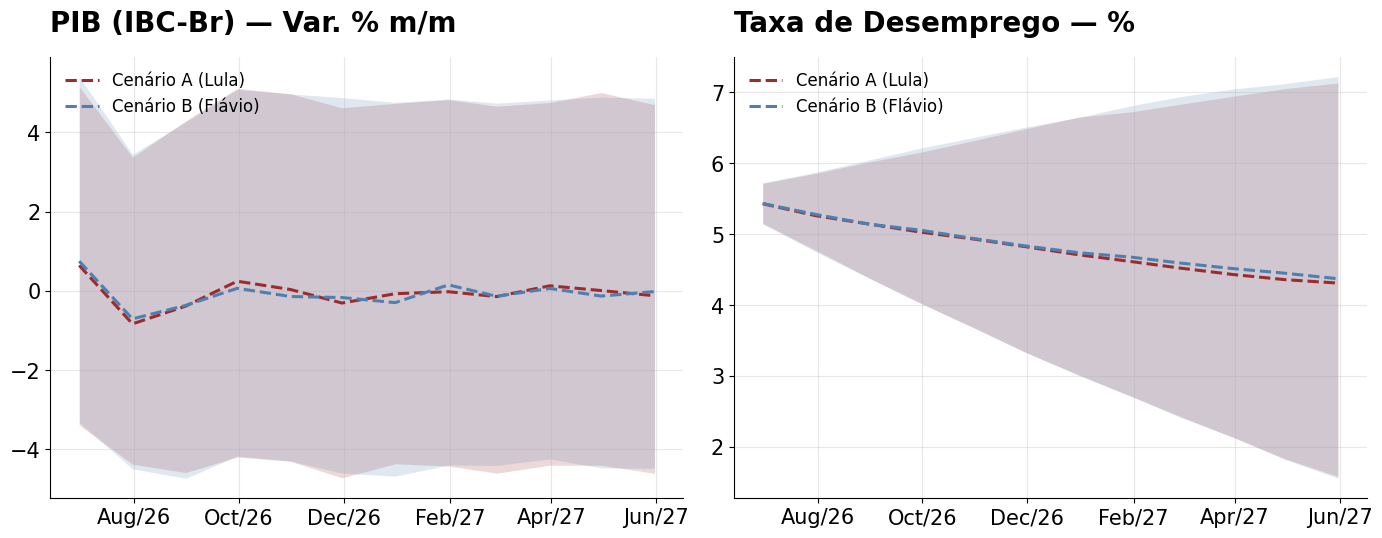

In [48]:
# ══════════════════════════════════════════════════════════════════════════════
#  BLOCO 6 — Gráfico executivo: PIB e Desemprego projetados
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for cenario, r in resultado_real.items():
    cor = cores_cenario[cenario]
    label = "Cenário A (Lula)" if "A_Lula" in cenario else "Cenário B (Flávio)"
    axes[0].plot(datas_real, r["pib_mediana"], color=cor, linestyle="--", linewidth=2.2, label=label)
    axes[0].fill_between(datas_real, r["pib_p10"], r["pib_p90"], alpha=0.18, color=cor, linewidth=0)
    axes[1].plot(datas_real, r["desemp_mediana"], color=cor, linestyle="--", linewidth=2.2, label=label)
    axes[1].fill_between(datas_real, r["desemp_p10"], r["desemp_p90"], alpha=0.18, color=cor, linewidth=0)

axes[0].set_title("PIB (IBC-Br) — Var. % m/m", loc="left")
axes[1].set_title("Taxa de Desemprego — %", loc="left")
for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%y"))
    ax.legend(loc="upper left", frameon=False)
    ax.spines[["top", "right"]].set_visible(False)

fig.autofmt_xdate(rotation=0, ha="center")
fig.tight_layout()
plt.savefig("pib_desemprego_cenarios.png", dpi=300, bbox_inches="tight")
plt.show()

# MATERIAL ADICIONAL

Blocos complementares que **não alimentam** a cadeia causal estimada (não ponderam nenhuma simulação do Módulo 1) — mantidos à parte para não sugerir uma dependência que não existe no código.

## A.1 Expectativa Polymarket (leitura complementar de mercado, sem peso na simulação)

In [20]:
SLUG = "brazil-presidential-election"
CANDIDATOS = ["Luiz Inácio Lula da Silva", "Flávio Bolsonaro"]
HORA_FECHAMENTO = 17  # UTC
DATA_INICIO = "2026-01-01"

def buscar_mercados(slug):
    eventos = requests.get(f"https://gamma-api.polymarket.com/events?slug={slug}").json()
    if not eventos:
        raise ValueError(f"Evento '{slug}' não encontrado.")
    return eventos[0].get("markets", [])

def historico_candidato(mercado):
    token_ids = mercado.get("clobTokenIds", "[]")
    token_ids = json.loads(token_ids) if isinstance(token_ids, str) else token_ids
    if not token_ids:
        return None

    url = f"https://clob.polymarket.com/prices-history?market={token_ids[0]}&interval=max&fidelity=60"
    r = requests.get(url)
    if r.status_code != 200:
        print(f"❌ Erro {r.status_code} para {mercado.get('groupItemTitle')}")
        return None

    dados = r.json().get("history", [])
    if not dados:
        return None

    df = pd.DataFrame(dados)
    df["data"] = pd.to_datetime(df["t"], unit="s")
    df = df.set_index("data")

    fechamento = df.between_time("00:00", f"{HORA_FECHAMENTO}:00").resample("D").last()
    fechamento = fechamento.loc[fechamento.index >= DATA_INICIO]
    return fechamento["p"].rename(mercado.get("groupItemTitle"))

mercados = [m for m in buscar_mercados(SLUG) if m.get("groupItemTitle") in CANDIDATOS]
print(f"Filtrados {len(mercados)} mercados.")

series = {}
for m in mercados:
    s = historico_candidato(m)
    if s is not None:
        series[m["groupItemTitle"]] = s
        print(f"✅ {m['groupItemTitle']}")
    time.sleep(1.5)

if len(series) == 2:
    df_final = pd.concat(series.values(), axis=1).ffill().fillna(0)
    df_final["Outros"] = (1 - df_final.sum(axis=1)).clip(lower=0)
    df_final = df_final.reset_index()
    df_final.to_csv("historico_polymarket_lula_flavio_outros.csv", index=False)
    print(df_final.tail(10))
else:
    print("Não foi possível obter os dois candidatos.")

Filtrados 2 mercados.
✅ Luiz Inácio Lula da Silva
✅ Flávio Bolsonaro
         data  Luiz Inácio Lula da Silva  Flávio Bolsonaro  Outros
20 2026-07-01                      0.575            0.2305  0.1945
21 2026-07-02                      0.605            0.2185  0.1765
22 2026-07-03                      0.605            0.2195  0.1755
23 2026-07-04                      0.605            0.2210  0.1740
24 2026-07-05                      0.605            0.2230  0.1720
25 2026-07-06                      0.615            0.2215  0.1635
26 2026-07-07                      0.615            0.2225  0.1625
27 2026-07-08                      0.615            0.2225  0.1625
28 2026-07-09                      0.615            0.2295  0.1555
29 2026-07-10                      0.605            0.2255  0.1695


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  A.2 — Exportação dos bancos de dados utilizados em cada etapa
# ══════════════════════════════════════════════════════════════════════════════
# Salva em CSV os principais DataFrames de cada módulo, para auditoria externa
# e para permitir reabrir o relatório sem precisar reexecutar as coletas via API.

import os
os.makedirs("dados_utilizados", exist_ok=True)

_exportaveis = {
    # Módulo 1.1 — Desenrola
    "1_1_desenrola_bruto"          : "df",
    "1_1_desenrola_dessazonalizado": "df_dessaz",
    # Módulo 1.2 — Fim da Escala 6x1
    "1_2_6x1_series"               : "df_6x1",
    # Módulo 1.3 — Eleições 2026
    "1_3_eleicoes_periodo_A_lula"      : "df_periodo_A",
    "1_3_eleicoes_periodo_B_bolsonaro" : "df_periodo_B",
    # Módulo 2 — Fluxo de Capitais
    "2_fluxo_capitais"             : "df_fluxo",
    # Módulo 3 — Ibovespa
    "3_ibovespa_painel"            : "painel",
    # Módulo 4 — Economia Doméstica
    "4_painel_real"                : "painel_real",
    "4_painel_ardl_pib"            : "painel_ardl",
    "4_painel_okun_desemprego"     : "painel_okun",
}

salvos, ausentes = [], []
for nome_arquivo, nome_var in _exportaveis.items():
    obj = globals().get(nome_var)
    if obj is not None and hasattr(obj, "to_csv"):
        caminho = f"dados_utilizados/{nome_arquivo}.csv"
        obj.to_csv(caminho)
        salvos.append(caminho)
    else:
        ausentes.append(nome_var)

print(f"✔  {len(salvos)} bancos de dados exportados para ./dados_utilizados/")
for c in salvos:
    print(f"   - {c}")
if ausentes:
    print(f"\n⚠️  Variáveis não encontradas no namespace (confira o nome exato ao reexecutar): {ausentes}")
